# Predicción de Churn - Retención de Clientes

La retención de clientes es un factor clave en la rentabilidad de cualquier empresa, ya que el costo de adquisición de nuevos clientes suele ser significativamente mayor que el de mantener los existentes.

En este proyecto se desarrolla un modelo de machine learning orientado a predecir la probabilidad de churn (abandono del cliente).


## Descripcion de Variables.
Variable objetivo:

* 1 = Churn (Cliente con posibilidad de abandono)
* 0 = No Churn (Cliente retenido)

* gender = Género del cliente (Male / Female)

* SeniorCitizen = Indica si el cliente es adulto mayor (1 = Sí, 0 = No)

* Partner = Si el cliente tiene pareja (Yes / No)

* Dependents = Si el cliente tiene dependientes (Yes / No)

* tenure = Tiempo (en meses) que el cliente lleva con la empresa.

* PhoneService = Si tiene servicio telefónico

* MultipleLines = Si tiene múltiples líneas telefónicas

* InternetService = Tipo de servicio de internet (DSL/Fiber optic /No)

* OnlineSecurity = Seguridad en línea

* OnlineBackup = Respaldo en la nube

* DeviceProtection = Protección de dispositivos

* TechSupport = Soporte técnico

* StreamingTV = Servicio de TV

* StreamingMovies = Servicio de películas

* Contract = Tipo de contrato. (Month-to-month /One year /Two year)

* PaperlessBilling = Facturación digital.

* PaymentMethod =Método de pago. (Electronic check / Mailed check / Bank transfer / Credit card)

* MonthlyCharges = Cargo mensual del cliente

* TotalCharges = Total pagado por el cliente



* Las variables incluyen características demográficas, servicios contratados, tipo de contrato y comportamiento de facturación, lo que permite analizar el churn desde múltiples dimensiones: comportamiento del cliente, nivel de engagement y factores económicos.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import make_scorer
from sklearn.utils import shuffle
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score,log_loss, make_scorer
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', None)
from category_encoders import WOEEncoder
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
!pip install optuna
import optuna
from scipy.stats import ks_2samp
#set_config(transform_output="pandas")
from sklearn.metrics import roc_auc_score, recall_score, f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import shap



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv(r'C:\Users\jabes\Desktop\PORTAFOLIO CIENTIFICO DE DATOS\CHURN\playground-series-s6e3\train.csv')
df.drop(columns='id', inplace=True)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
print(f"{df.info()}")
print('*=' * 30)
print(f"{df.isna().sum()}")
print('*=' * 30)
print(f"{df.isnull().sum()}")
print('*='*30)
print(f"{df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

* En el DataSet no existen Null's y ni Nan, tenemos muchas variables discretas no numericas las mismas requeriran transformacion, algunas binarias.

## Análisis Exploratorio de Datos (EDA)

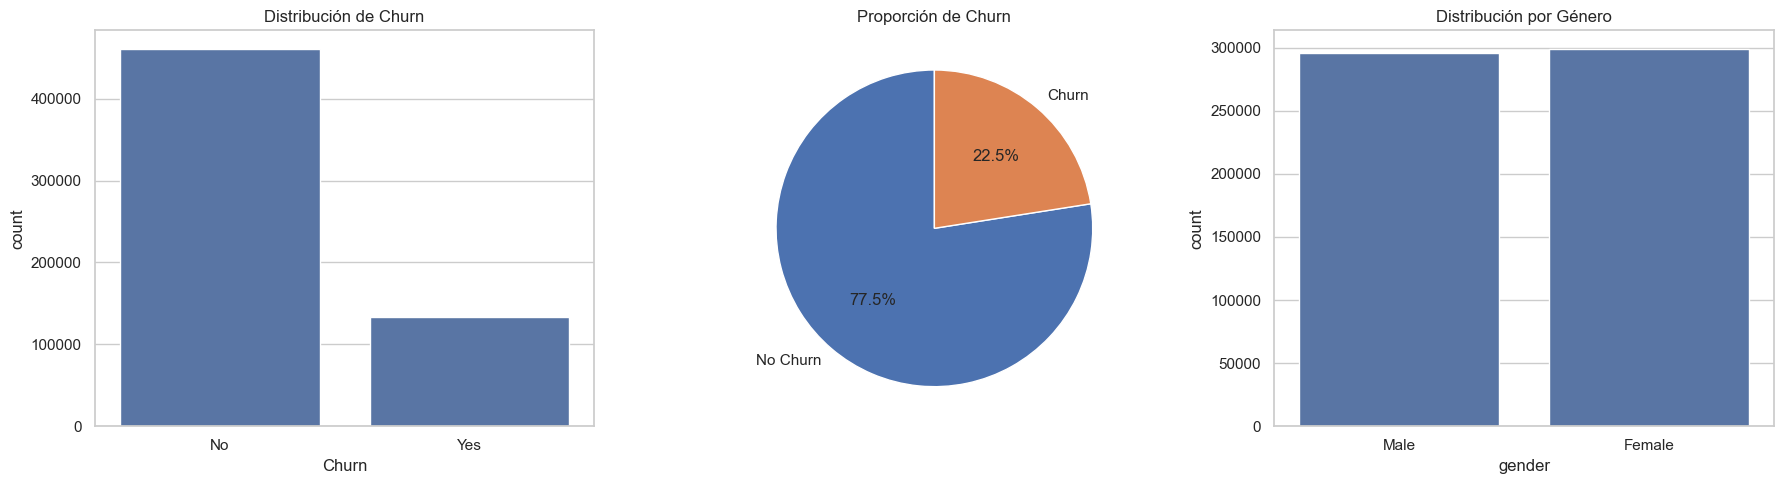

Churn
No     460377
Yes    133817
Name: count, dtype: int64
******************************
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64


In [4]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Distribución de Churn')


# Pie Chart (Churn)
churn_counts = df['Churn'].value_counts()
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Churn')


# Género

sns.countplot(x='gender', data=df, ax=axes[2])
#axes[2].set_yscale('log')
axes[2].set_title('Distribución por Género')

# Ajustar espacios
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print('**'*15)
print(df['gender'].value_counts(normalize=True)*100)

* El dataset presenta desbalance (22.5% churn vs 77.5% no churn), lo cual deberá considerarse en el modelado.

## Describe

In [5]:
def describe_modif(df):
    num_df = df.select_dtypes(include='number')
    desc = num_df.describe()
    desc.loc['count ceros'] = (num_df == 0).sum()
    desc.loc['count negativos'] = (num_df < 0).sum()
    desc.loc['count null'] = num_df.isna().sum()
    desc.loc['pct ceros'] = (num_df == 0).mean()
    desc.loc['pct negativos'] = (num_df < 0).mean()
    desc.loc['pct nulls'] = num_df.isna().mean()
    desc.loc['Coef. Variacion'] = desc.loc['std'] / desc.loc['mean']
    q1 = desc.loc['25%']
    q3 = desc.loc['75%']
    iqr = q3 - q1
    desc.loc['IQR'] = iqr
    outliers = ((num_df < (q1 - 1.5 * iqr))|(num_df > (q3 + 1.5 * iqr))).sum()
    desc.loc['Conteo de Outliers'] = outliers
    desc.loc['Asimetria'] = num_df.skew()
    percentiles = [0, 0.25,0.50, 0.75, 0.90,0.97, 0.98, 0.99,1]
    for p in percentiles:
        desc.loc[f'P{int(p*100)}'] = num_df.quantile(p)
    desc = desc.drop(index=['min','25%','50%','75%', 'max'])
    return desc.round(2)

describe_modif(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00
mean,0.11,36.58,65.87,2494.38
std,0.32,25.06,31.07,2353.92
count ceros,526395.00,0.00,0.00,0.00
count negativos,0.00,0.00,0.00,0.00
count null,0.00,0.00,0.00,0.00
pct ceros,0.89,0.00,0.00,0.00
pct negativos,0.00,0.00,0.00,0.00
pct nulls,0.00,0.00,0.00,0.00
Coef. Variacion,2.79,0.69,0.47,0.94


# Distribucion de Variables Numericas.

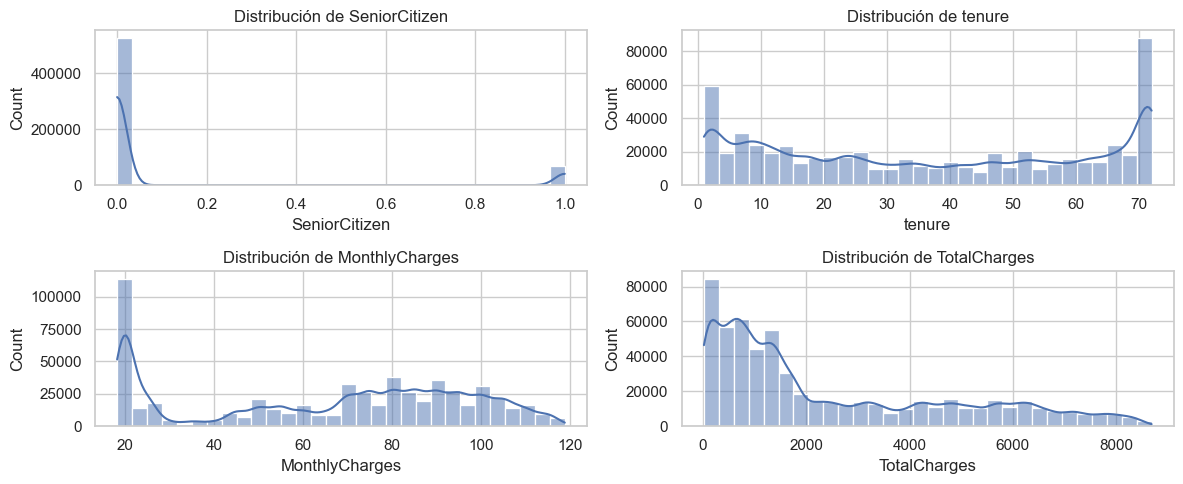

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,5))

numerical_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

for i, col in enumerate(numerical_col):
    row = i // 2
    col_idx = i % 2

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Observaciones Variables Numericas:

* La variable **SeniorCitizen** es una variable binaria, la cual indica que tenemos una poblacion en su mayoria joven.

* En **MonthlyCharges** confirmo la presencia de algunos bayes y Outliers, podria monstrar algun patron de subcripciones aumento de subscripciones en meses especificos.

* En **TotalCharges** se muestra una grafica decreciente con una fuerte concentracion de 0 a 1900 USD, cabe destacar que esta variable es medida en USD, tambien podria indicar que algunos clientes se atrasan levemente.

* En **Ternure** confirmo la existencia de Outliers los mismos indican una retencion balanceada por clientes viejos mostrando clientes que tienen mas de 70 meses con el servicio contratado, pero tambien muestra una gran masa de clientes que son nuevos y se tendria que buscar los puntos fuertes para hacer que duren en el tiempo.

# Distribucion de Variables Categoricas.

In [7]:
categorical_cols= df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["Churn", "gender"]]

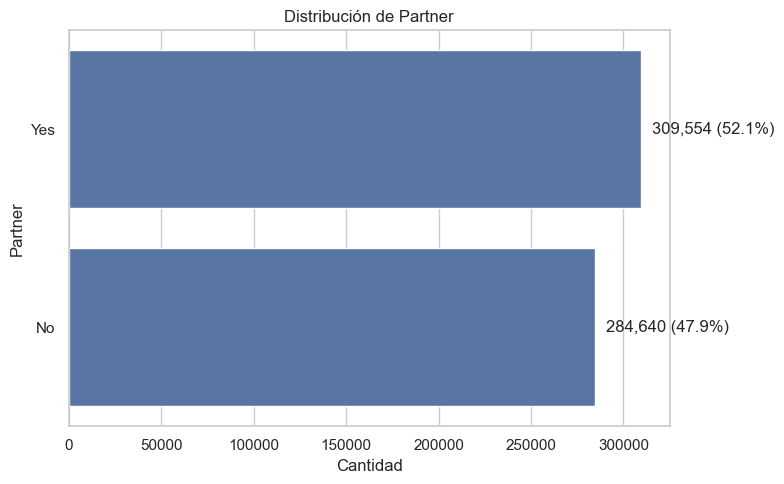

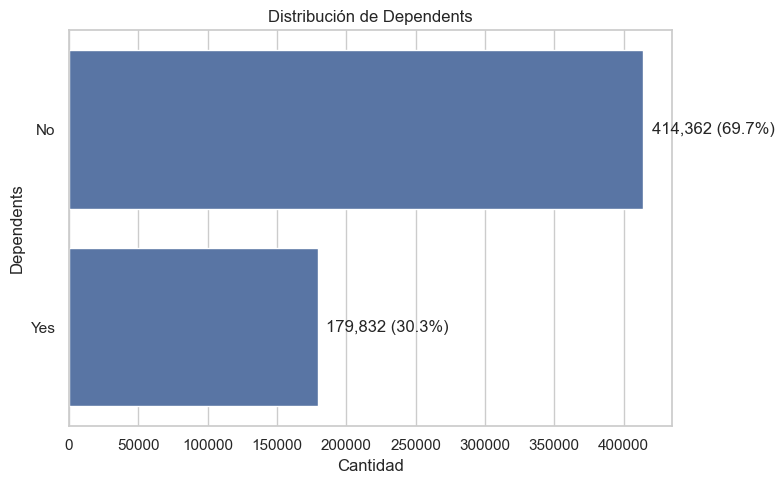

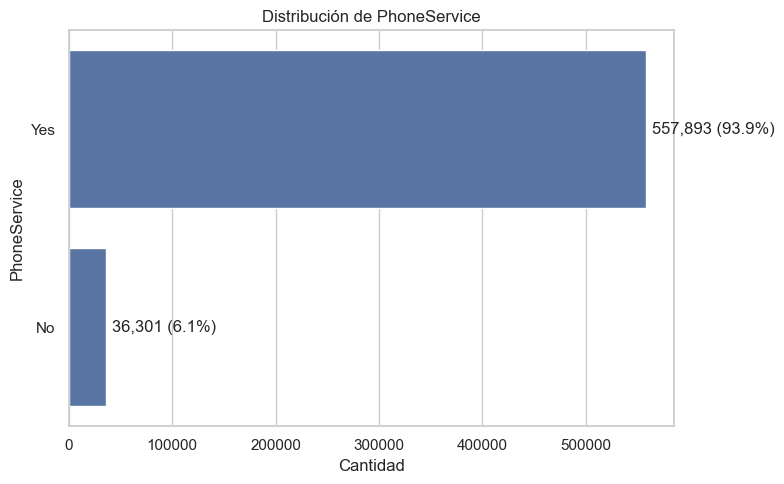

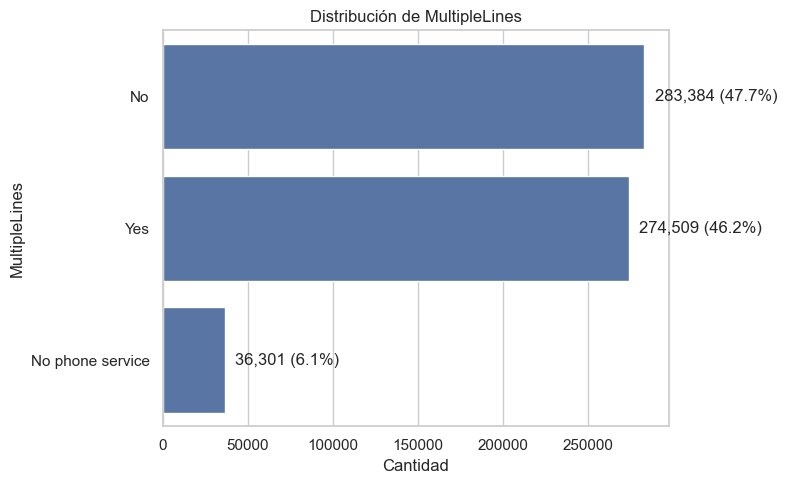

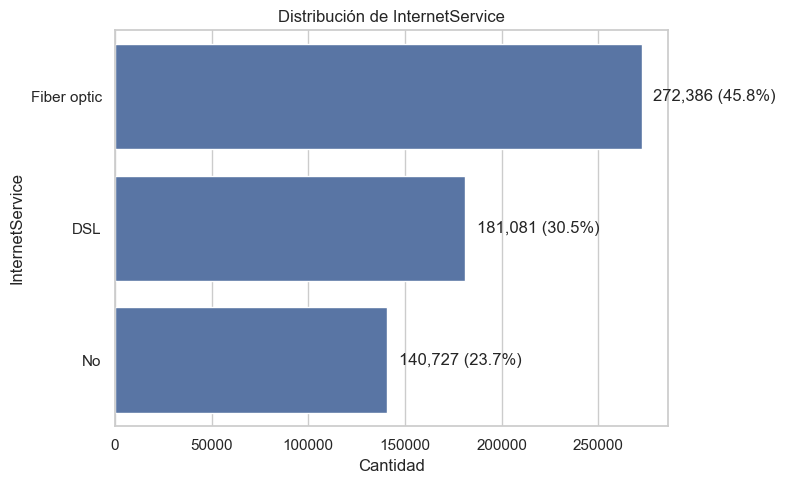

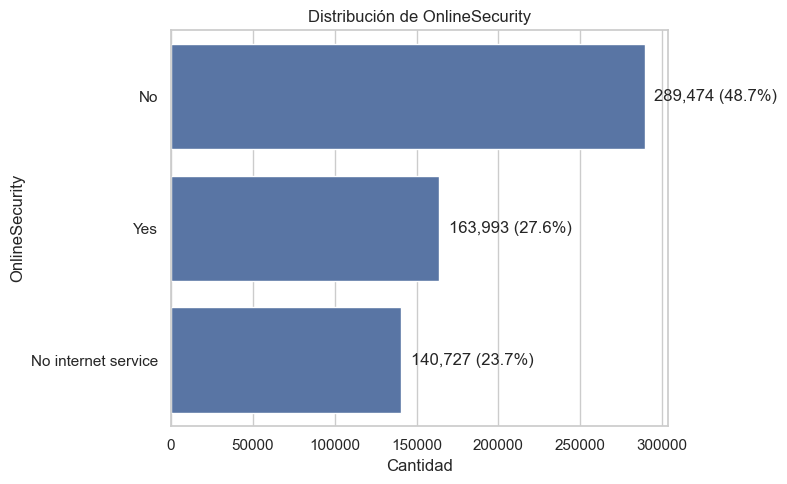

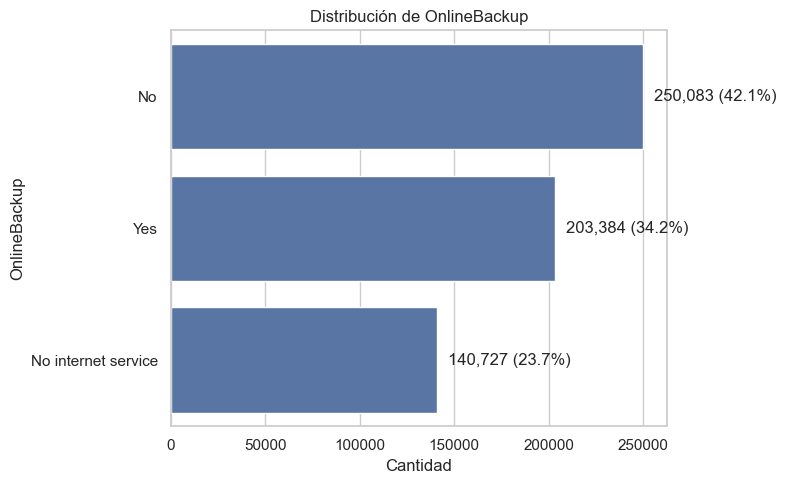

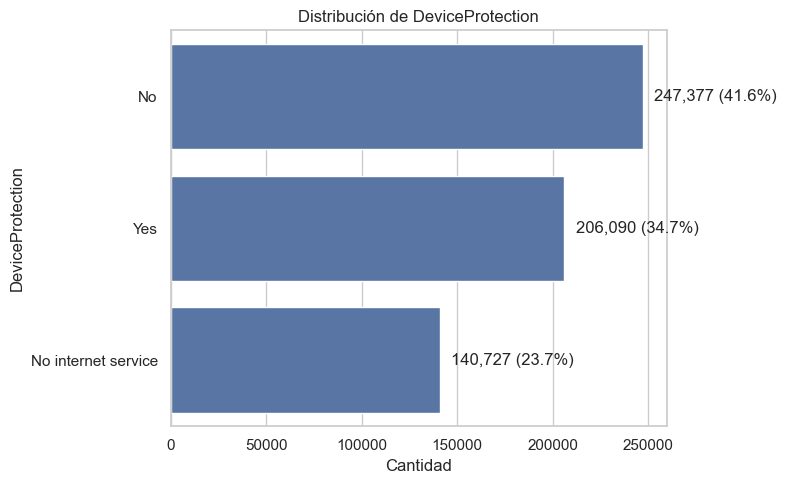

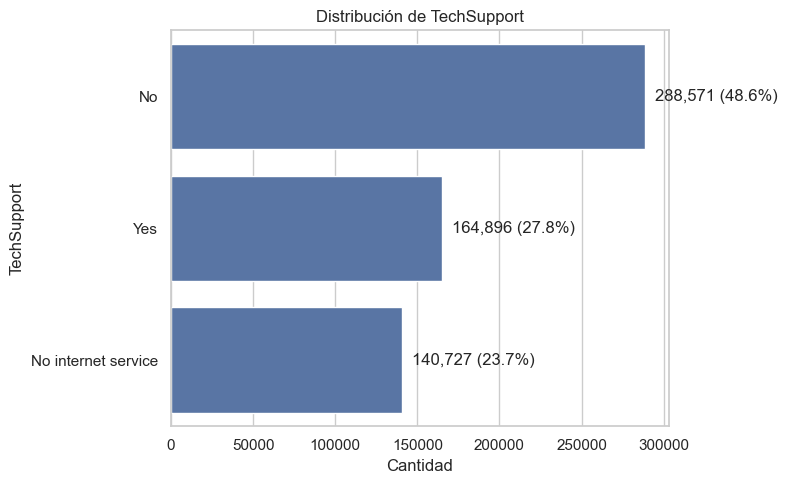

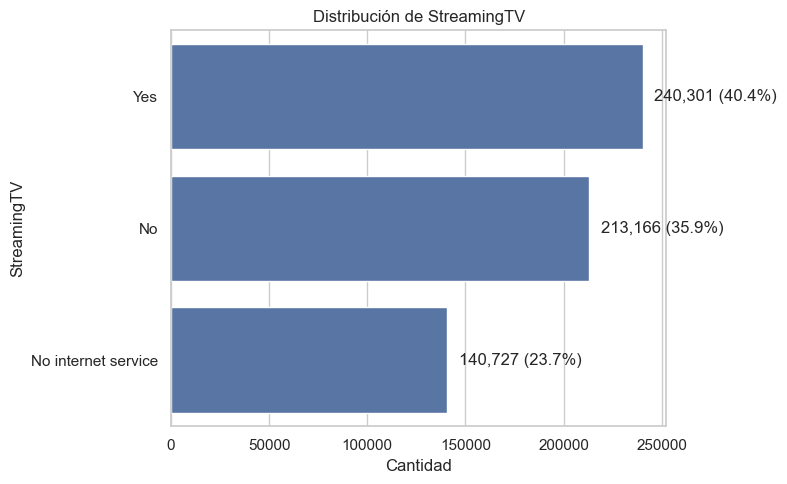

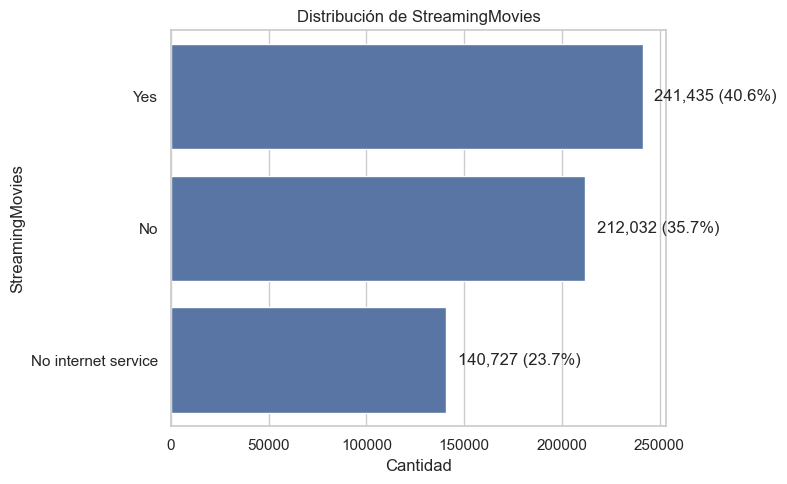

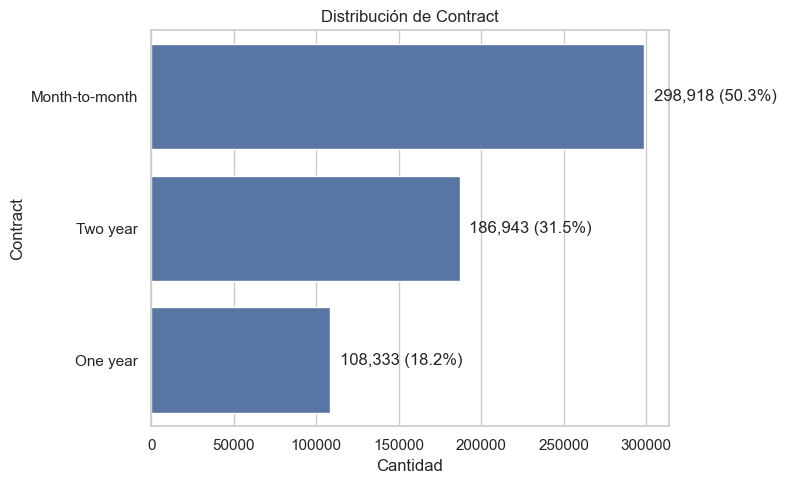

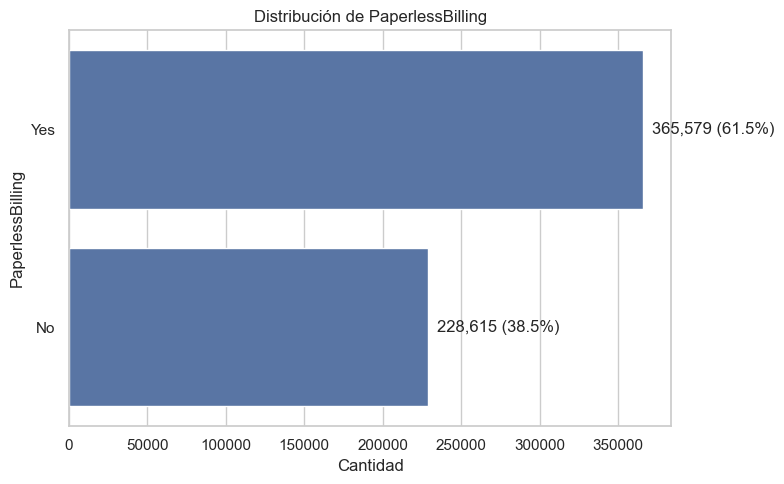

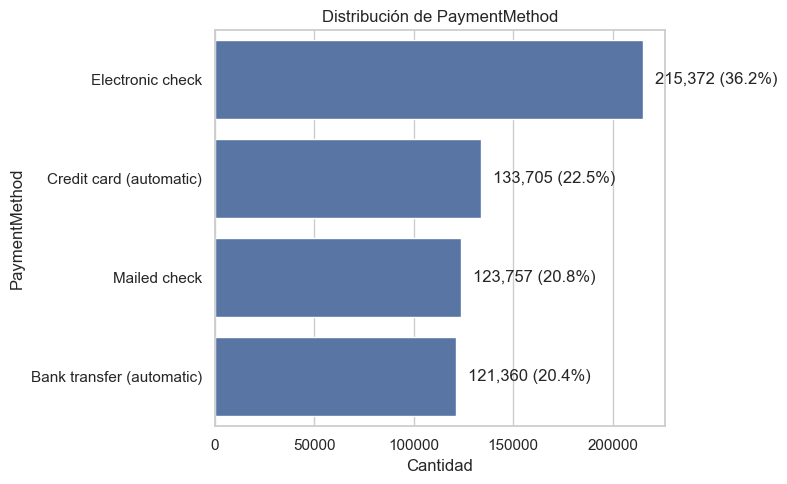

In [8]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))

    # Conteo
    counts = df[col].value_counts()
    total = len(df)

    # Crear barplot horizontal
    ax = sns.barplot(x=counts.values, y=counts.index)

    # Agregar labels con % y count
    for i, v in enumerate(counts.values):
        pct = (v / total) * 100
        ax.text(v + (total * 0.01), i, f'{v:,} ({pct:.1f}%)', va='center')

    plt.title(f'Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Observaciones de Variables Categóricas

* **Churn:** Se observa un fuerte desbalance en las clases, notando que el 22.5% de la población corresponde a clientes que abandonan el servicio brindado.
* **PaymentMethod:** El método de pago con mayor uso es **Electronic Check**, pero la utilización de los otros canales de pago (**Credit Card (automatic)**, **Bank Transfer**, **Mailed Check**) da indicios de que tenemos clientes que pertenecen a una población menos madura.
* **PaperlessBilling:** Más del 60% de los clientes tienen facturación digital. Sería interesante analizar el comportamiento de esta variable frente al **Churn**.
* **Contract:** Más del 50.3% de los clientes utilizan contratación mes a mes, lo que sugiere que son productos de suscripción. También se observa que el 31.5% de la clientela tiene un contrato de 2 años, indicando que podrían ser empresas.
* **StreamingMovies:** Esta variable confirma claramente que es una población relativamente joven. También levanta sospechas el hecho de que el 23.7% no tiene servicio de internet.
* **DeviceProtection:** Este servicio no es muy demandado, solo el 37.7% de la población lo tiene, mientras que el 23.7% muestra que no tiene internet.
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, InternetService:** Todas estas variables tienen algo en común que es una constante interesante: el 23.7% de su población no tiene suscrito el servicio de internet. Esto da a entender que existe una parte de la población que carece del servicio base, o bien, es una población madura que no presenta necesidad de este.
* **PhoneService:** El 94% de la población presenta servicio de teléfono.
* **gender:** La distribución entre géneros es normal y balanceada.
* **MultipleLines:** Más del 46% de los clientes poseen múltiples líneas de servicio contratado. Sería bueno analizar esta distribución con respecto a **Churn**.

# Analisis bivariado.

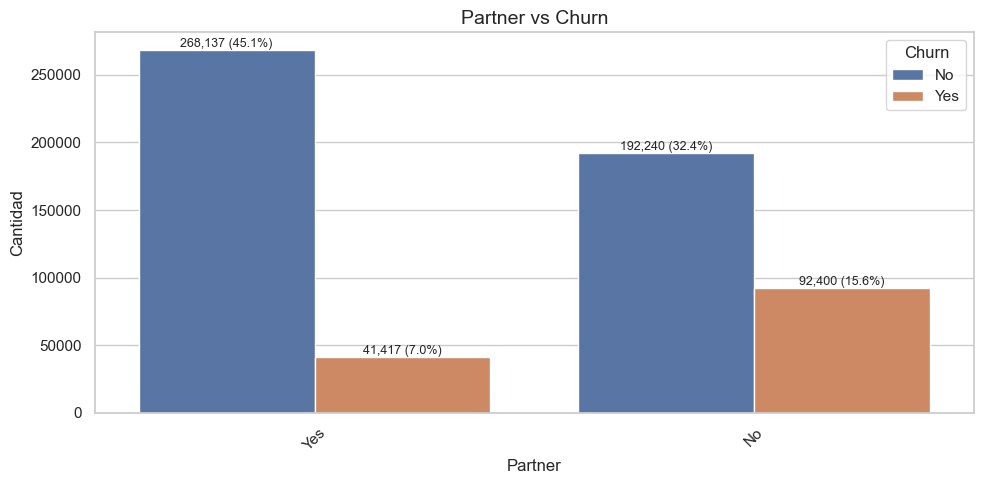

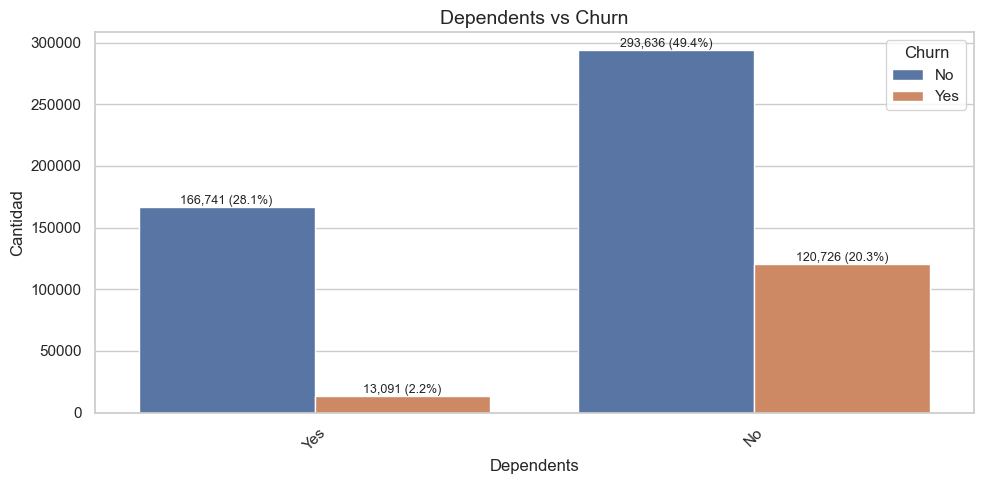

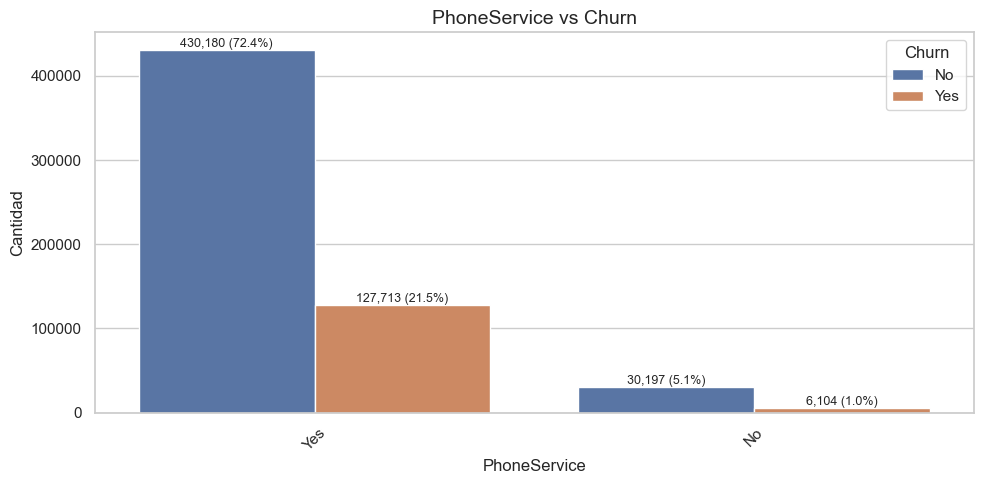

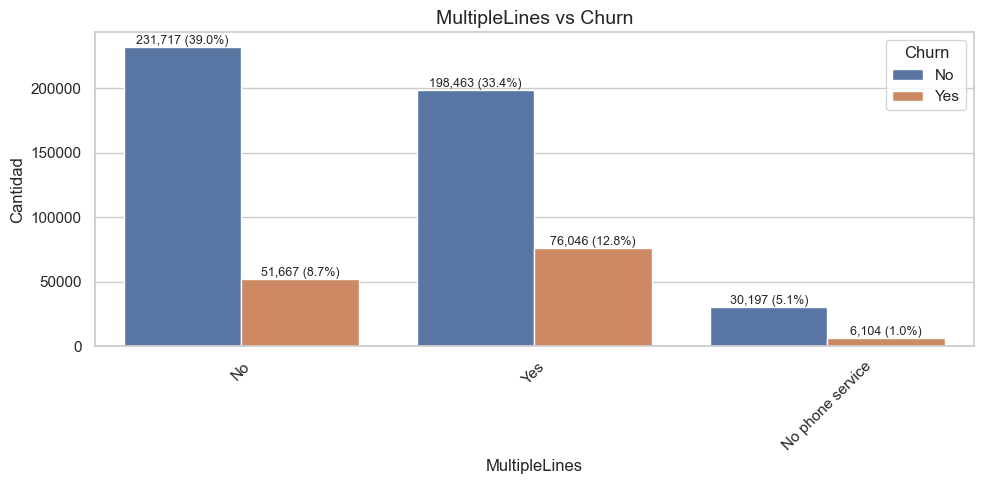

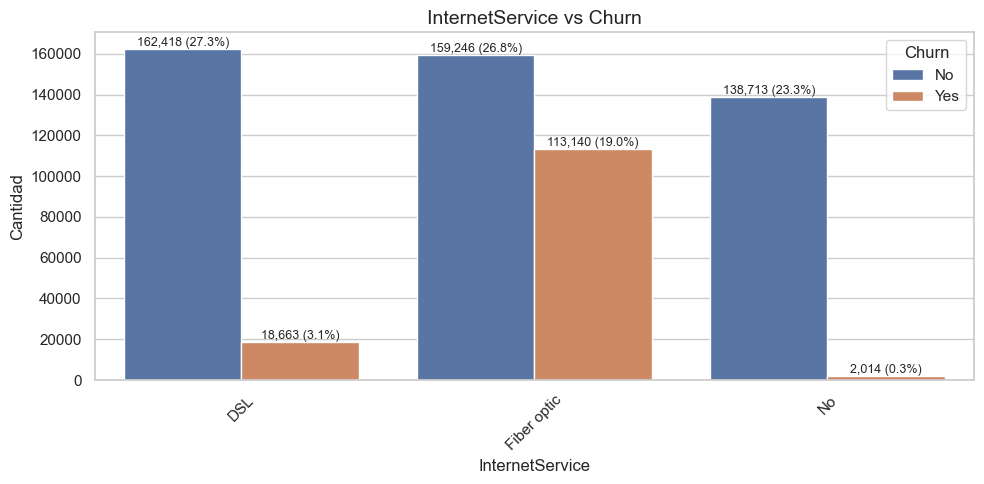

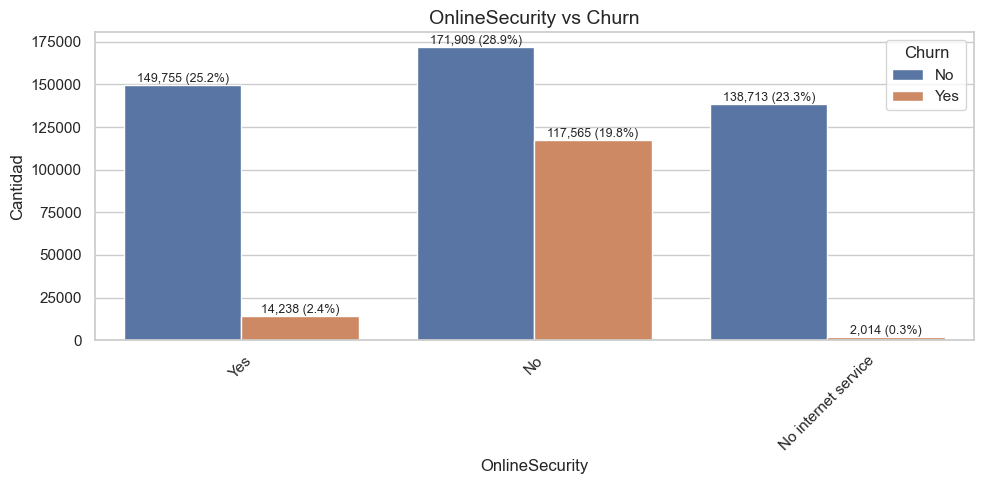

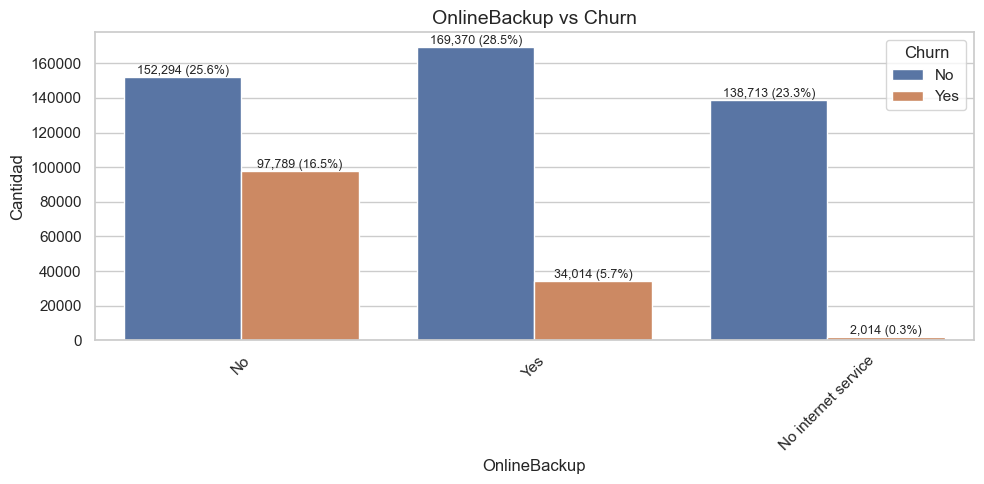

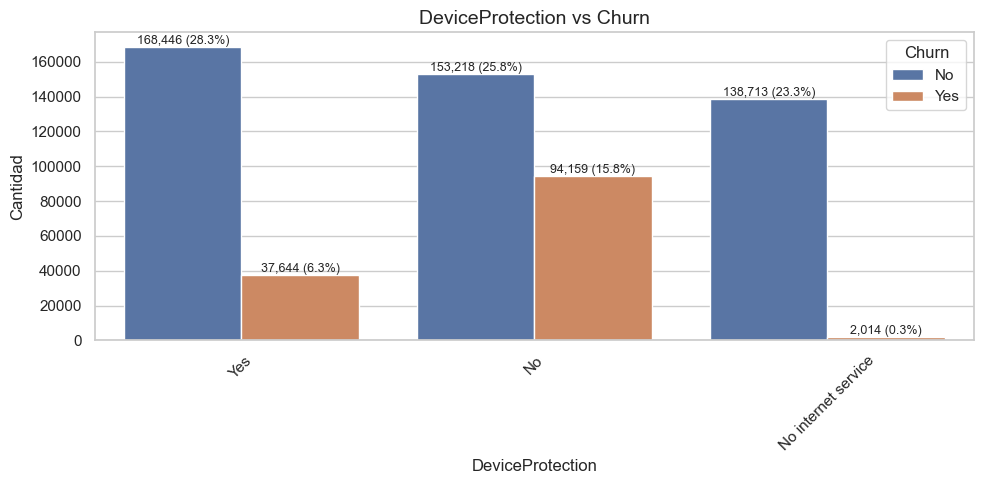

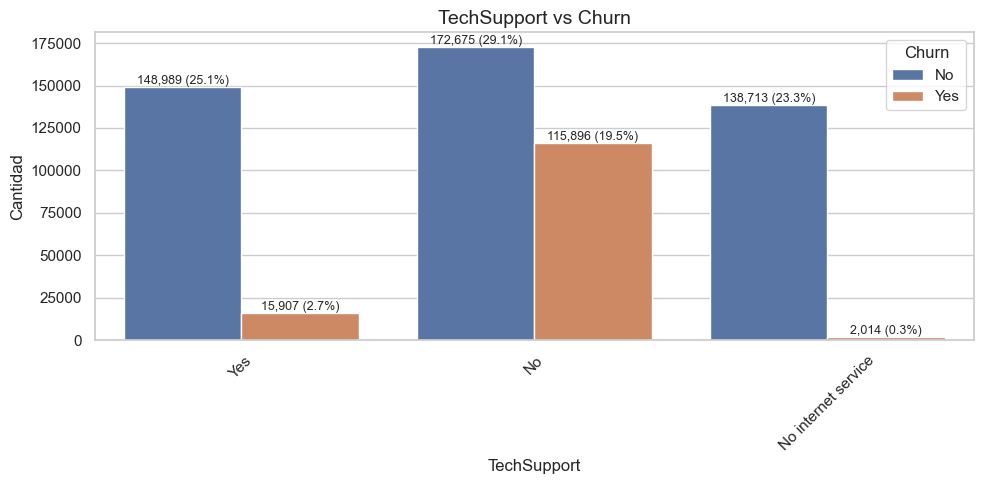

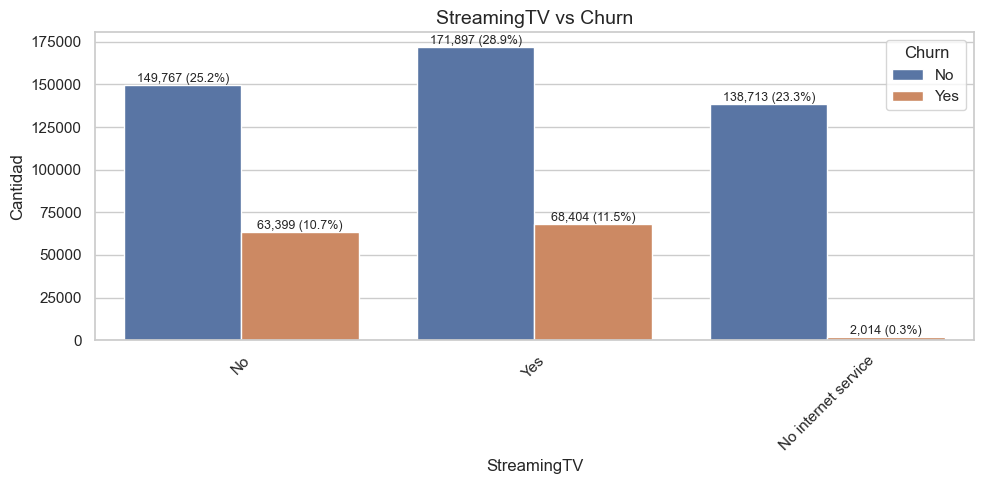

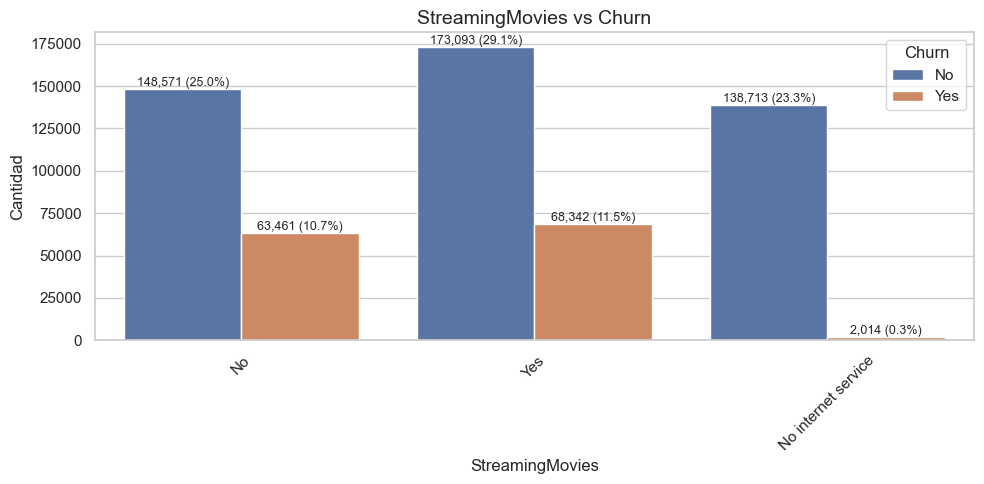

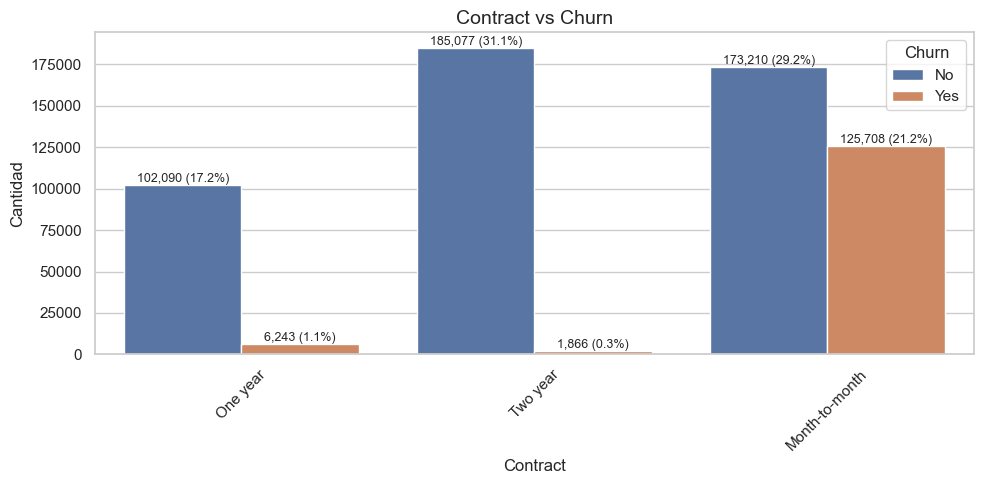

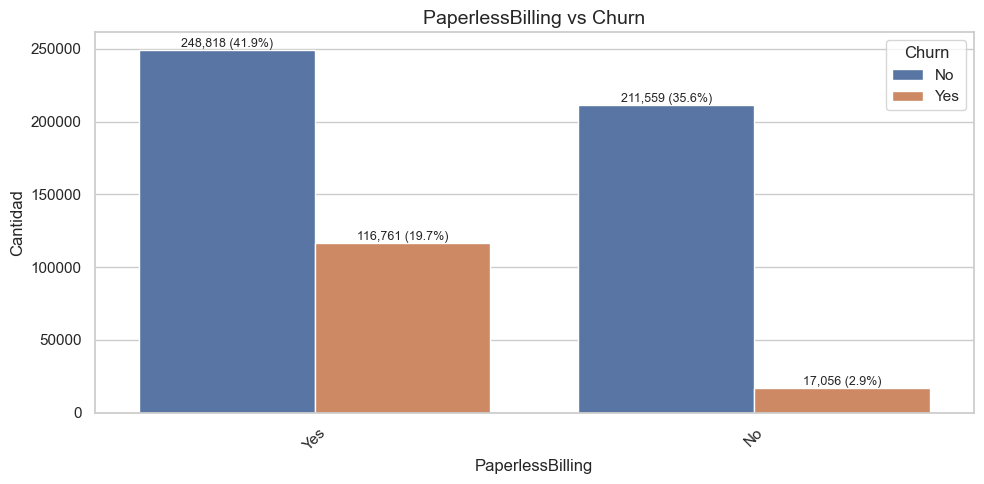

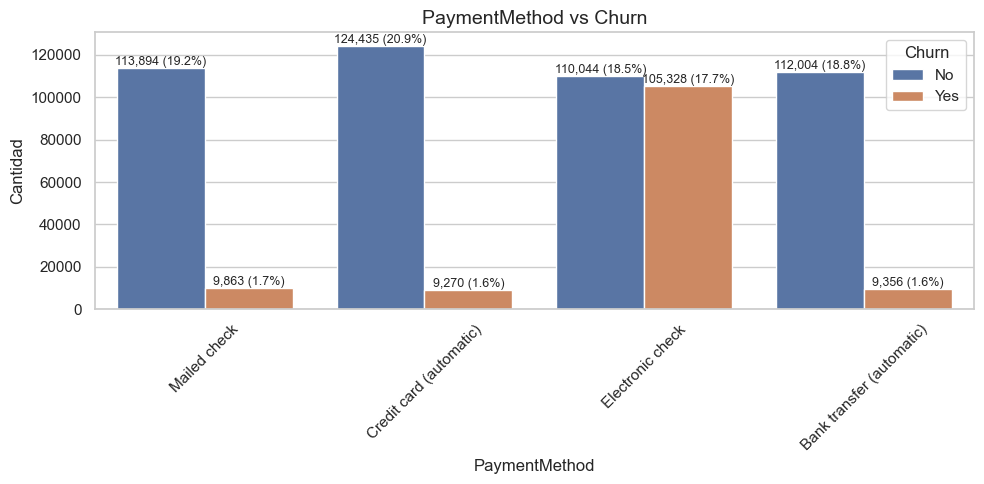

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, hue='Churn', data=df)
    total = len(df)

    # recorrer cada grupo de barras
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue
            pct = (height / total) * 100
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{int(height):,} ({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

* **MultiplesLines** indica que las personas con multiples lineas tienen un 13% de probablidad de cancelar el servicio, este comportamiento podria ser dado a saturacion de servicios contratados.

* **InternetService** esta variable me parece bastante interesante al hacer la comparativa con la variable objetivo, mostrando que dentro de la población dada los que tienen el servicio de Fiber Optic son los que tienen mas probabilidad de cancelar el mismo, esto quizas es dado a alguna inconformidad con el servicio siento este el 10% de la población.

* **OnlineSecurity** esta variable Tambien refleja un patron anomalo, el 19.8% de la población tiene alta probabilidad de churn porque no tiene servicio de Seguridad contratado, esto podria referirse a un patron de fraude.

* **PaymentMethod** el grafico confirmo algo que me llama bastante la atención, la gran masa de clientes con probabilidad de churn tienen el método de pago **Electrinic Check** esto representa el 17.7% de la población, luego de esto todos los otros métodos de pago reflejan menos del 1.8% de probabilidad de churn.

* **Contract** al ver esta variable contra churn se confirma que los clientes que pagan mes a mes son los que tienen mayor probabilidad de irse, en cambio los que tienen contratos mas largos tienen menos probabilidad, lo ideal seria ver la posibilidad de realizar contratos mas largos para poder reducir esto.

* **TechSuport & DeviceProtection** son variables muy similares en comportamiento, las mimas reflejan una alta posibilidad de churn en clientes que no cuentan con estos servicios.

* **InternetService** el churn en los clientes con Fibra Optica es bastante alto, representando esto el 19% de la población, vale la pena destacar que este servicio es Premium cuando lo comparamos con el DSL.

* **Dependents** las ciudadanos sin dependientes reflejan el 20.3% de la población churn del dataset.

## Selección del Codificador Categórico

In [10]:

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

# Columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(exclude=['object']).columns.tolist()

# Train / Test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, stratify=y
)

# Función KS (la mantengo igual)
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df_ks = df_ks.sort_values('prob')
    df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    df_ks['cum_bad']  = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    return np.max(np.abs(df_ks['cum_good'] - df_ks['cum_bad']))

# ====================== PIPELINES ======================

#  One Hot Encoding + Escalado
ohe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])

# Target Encoding + Escalado
tg_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

#  WOE Encoding
woe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', WOEEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])


pipelines = {
    "One Hot Encoding": ohe_pipe,
    "Target Encoding": tg_pipe,
    "WOE (Librería)": woe_pipe
}

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'KS': ks_statistic(y_test, y_prob)
    })

# Resultados finales
results_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
display(results_df)

,Model,AUC,Accuracy,F1,KS
0,One Hot Encoding,0.907549,0.806242,0.671601,0.665212
2,WOE (Librería),0.907538,0.854425,0.671140,0.665419
1,Target Encoding,0.907172,0.853827,0.669985,0.665156


Se compararon tres técnicas de codificación (OHE, Target Encoding y WOE). El **Weight of Evidence (WoE)** fue el que mejor balance general presentó y, especialmente, destaca por su capacidad de reflejar la relación entre cada categoría y la variable objetivo (*Churn*).

---

## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Antes del Feature Engineering

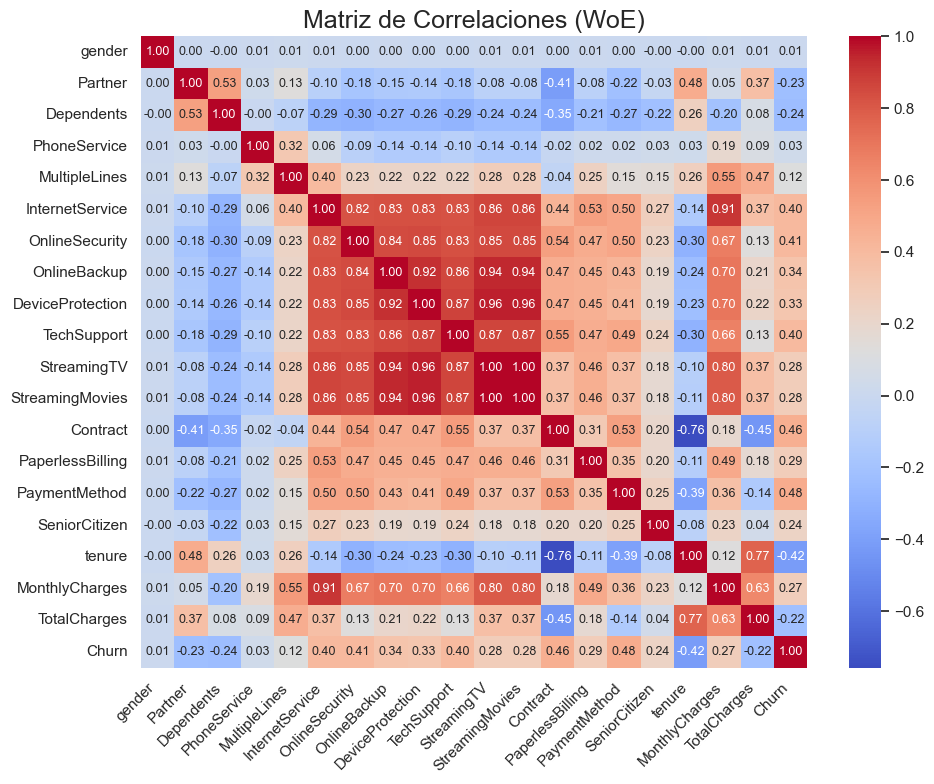

In [11]:
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns='Churn')


binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = X[col].map({'Yes': 1, 'No': 0}).astype(int)

# Columnas originales
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

#  Verificación
missing = [col for col in cat_cols + num_cols if col not in X.columns]


#  Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Crear DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()



sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Variance Inflation Factor VIF

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = df_en.drop(columns=['Churn'])      
X = X.select_dtypes(include=['number'])

# Agregamos constante
X = add_constant(X)

# calculo VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("VIF para todas las variables:")
vif_df = pd.DataFrame(vif_data, columns=['Variable', 'VIF'])
vif_df

VIF para todas las variables:


,Variable,VIF
0,StreamingTV,2498.699874
1,StreamingMovies,2428.364030
2,const,106.778683
3,MonthlyCharges,24.416056
4,InternetService,19.542926
5,DeviceProtection,18.266045
6,OnlineBackup,12.061593
7,TotalCharges,10.467508
8,tenure,7.160645
9,TechSupport,6.781358


## Information Value IV

In [13]:
def calculate_iv(df, target_col='Churn', bins=10):

    iv_dict = {}
    df = df.copy()

    for col in df.columns:
        if col == target_col:
            continue
            
        # Bines
        if df[col].dtype in ['int64', 'float64']:
            df['bin'] = pd.qcut(df[col], q=bins, duplicates='drop')
        else:
            df['bin'] = df[col]
        
        # Calcular distribuciones
        grouped = df.groupby('bin', observed=False)[target_col].agg(['count', 'sum'])
        
        grouped['non_event'] = grouped['count'] - grouped['sum']
        grouped['event_rate'] = grouped['sum'] / grouped['sum'].sum()
        grouped['non_event_rate'] = grouped['non_event'] / grouped['non_event'].sum()
        
        # Evita Log(0)
        grouped['event_rate'] = grouped['event_rate'].replace(0, 0.0001)
        grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)
        
        # Calcular WoE e IV
        grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
        grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
        
        iv_total = grouped['iv'].sum()
        iv_dict[col] = round(iv_total, 4)
    
    iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
    iv_df = iv_df.sort_values(by='IV', ascending=False)
    
    return iv_df


iv_results = calculate_iv(df_en, target_col='Churn', bins=10)   
iv_results

,IV
Contract,1.8283
PaymentMethod,1.3523
tenure,1.3069
OnlineSecurity,1.2610
InternetService,1.1674
TechSupport,1.1672
MonthlyCharges,1.0594
OnlineBackup,0.6812
DeviceProtection,0.5786
TotalCharges,0.4242


## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Antes del Feature Engineering

Tras aplicar la transformación **Weight of Evidence (WoE)** al dataset original, analicé la matriz de correlaciones, el **Variance Inflation Factor (VIF)** y el **Information Value (IV)**.

**Observaciones principales de la matriz de correlación:**

- **Perfil Demográfico:** `Gender` (~0.01) y `SeniorCitizen` (~0.24) muestran poca o moderada relación con *Churn*. `Partner` y `Dependents` tienen correlación moderada (0.53).
- **Servicios y Cargos:** Identifiqué un bloque de alta correlación (0.80–0.96) entre servicios adicionales (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). `MonthlyCharges` e `InternetService` están muy correlacionados (0.91). `TotalCharges` está fuertemente ligada a `tenure` (0.77).
- **Factores de Riesgo de Abandono:** `PaymentMethod` (Electronic check) presenta la correlación positiva más alta con *Churn* (~0.48), seguido de `Contract` (~ -0.35). `OnlineSecurity` y `TechSupport` muestran correlación negativa (~ -0.30).

**Análisis del VIF:**
Detecté alta multicolinealidad en servicios de streaming (`StreamingTV` ≈ 2499, `StreamingMovies` ≈ 2428). Otras variables con VIF elevado: `MonthlyCharges` (24.42), `InternetService` (19.54) y `TotalCharges` (10.47 / 7.83). Decidí eliminar `TotalCharges` por su VIF cercano al umbral y menor correlación con *Churn* frente a `tenure`.

**Análisis del Information Value (IV):**
- Muy fuerte: `Contract` (1.8283), `PaymentMethod` (1.3523), `tenure` (1.3069), `OnlineSecurity` (1.2610), `InternetService` (1.1674).
- La mayoría de variables demográficas (`gender`, `Partner`, `Dependents`, etc.) tienen **IV = 0.0000**.

**Conclusión:**  
Identifiqué alta redundancia y multicolinealidad en los servicios adicionales, junto con un grupo claro de variables predictivas. Estas observaciones me motivaron a realizar el Feature Engineering para reducir ruido y mejorar la estabilidad de los modelos.

**Nota:** Todas las asociaciones son correlacionales y **no implican causalidad**.

## Feature Engineering: Propuestas de Transformación

### Creación de la Variable `Sag` (Servicios Agregados)
Creé una variable sintética categórica para simplificar la redundancia:

* **`Sag = 1`**: Más de 2 servicios adicionales.
* **`Sag = 0`**: 2 o menos servicios adicionales.


---

## Feature Engineering y Transformaciones

In [14]:

servicio = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


diccionario_mapeo = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0
}

# Sag
df['Sag'] = 0

for i in servicio:
    df[i] = df[i].map(diccionario_mapeo).fillna(0).astype(int)
    df['Sag'] += df[i]

df['Sag'] = (df['Sag'] > 2).astype(int)

# Is_New
df['Is_New'] = (df['tenure'] < 6).astype(int)



# Avg_charges
df['Avg_Charges'] = df['TotalCharges'] / (df['tenure'] + 1)



# Cliente de alto riesgo
df['High_Risk'] = (
    (df['tenure'] < 12) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

# Eliminar las columnas originales que ya fueron transformadas o consolidadas

df.drop(columns=[
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges'
], inplace=True)

Como se mencionó anteriormente, se creó la variable **Sag (Servicios Agregados)**. Esta variable binaria toma el valor de:

- **1**: clientes con más de dos servicios adicionales contratados.
- **0**: clientes con dos o menos servicios adicionales.

Esta transformación permite reducir la dimensionalidad agrupando múltiples variables relacionadas con servicios en una sola característica representativa.

La variable **Is_New** identifica clientes con menos de 6 meses dentro de la empresa. Este grupo representa clientes con mayor probabilidad de churn y sobre los cuales la empresa debería enfocar mayores esfuerzos de retención.


La variable **Avg_Charges** calcula el promedio de pagos realizados por cliente en función de su permanencia, permitiendo identificar diferencias de comportamiento entre clientes de mayor y menor valor.

Finalmente, la variable **High_Risk** identifica clientes con menos de un año en la empresa, contratos *Month-to-Month* y método de pago *Electronic Check*. Como se observó en el análisis exploratorio, este patrón está asociado a un mayor riesgo de churn.

---

## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Después del Feature Engineering

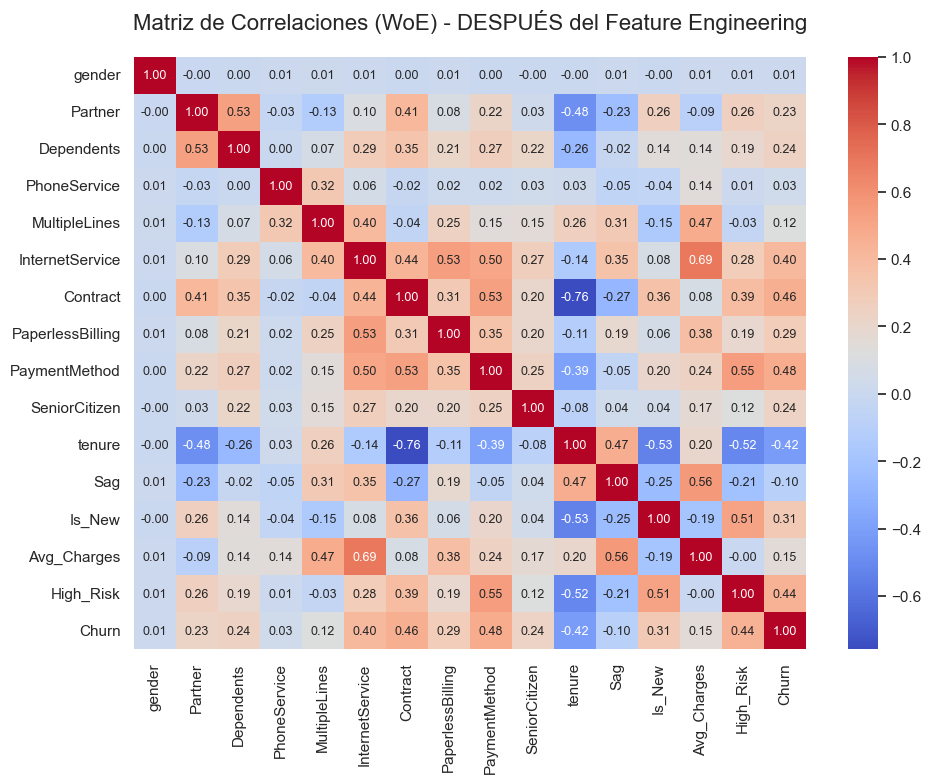

In [15]:

if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns=['Churn'])

#  Columnas automáticas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()


# Preprocesador con WOE (versión correcta)
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(regularization=1.0), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Reconstruir DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Corrección de infinitos (seguridad extra)
df_en = df_en.replace([np.inf, -np.inf], np.nan)
df_en = df_en.fillna(0)

# Matriz de correlación + Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE) - DESPUÉS del Feature Engineering',
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()


# Variance Inflation Factor VIF

In [16]:
X = df_en.drop(columns=['Churn'])      
X = X.select_dtypes(include=['number'])

# Agregamos constante
X = add_constant(X)

# calculo VIF para cada Variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)


print("VIF para todas las variables:")
_vif_df = pd.DataFrame(vif_data, columns=['Variable', 'VIF'])
_vif_df

VIF para todas las variables:


,Variable,VIF
0,const,17.759599
1,tenure,4.055429
2,Contract,3.662004
3,InternetService,3.500886
4,Avg_Charges,2.809573
5,High_Risk,2.080413
6,PaymentMethod,2.027156
7,Sag,1.947918
8,Partner,1.737901
9,Is_New,1.651931


## Information Value

In [17]:
iv_results = calculate_iv(df_en, target_col='Churn', bins=10)   
iv_results

,IV
Contract,1.8283
PaymentMethod,1.3523
tenure,1.3069
InternetService,1.1674
Avg_Charges,0.6585
MultipleLines,0.0758
Dependents,0.0000
PhoneService,0.0000
gender,0.0000
Partner,0.0000


## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Después del Feature Engineering

Tras aplicar la transformación **Weight of Evidence (WoE)** y las transformaciones de Feature Engineering, analicé la matriz de correlaciones, el **Variance Inflation Factor (VIF)** y el **Information Value (IV)**.

**Observaciones principales de la matriz de correlación:**
- Las variables más fuertemente asociadas al abandono son `High_Risk` (~0.44) .
- `InternetService` presenta una correlación relevante (~0.40).
- `Is_New` (~0.31) y `PaperlessBilling` (~0.29) también aportan valor predictivo.
- Persiste una correlación alta entre `InternetService` y `Avg_Charges` (~0.69).
- Variables como `gender` (~0.01) y `PhoneService` (~0.03) muestran correlaciones prácticamente nulas con *Churn*.

**Análisis del VIF:**
Ninguna variable supera el umbral crítico de multicolinealidad (VIF ≥ 8, excluyendo la constante). Los valores más altos corresponden a `tenure` (4.06), `Contract` (3.66) e `InternetService` (3.50), seguidos por `Avg_Charges` (2.81). El resto de las variables, incluidas las sintéticas (`High_Risk` = 2.08, `Sag` = 1.95, `Is_New` = 1.65), se mantiene en niveles bajos, sin evidencia de multicolinealidad relevante entre los predictores.

**Análisis del Information Value (IV):**
Después del Feature Engineering, las variables con mayor poder predictivo univariado fueron Contract (1.8283), PaymentMethod (1.3523), tenure (1.3069), InternetService (1.1674) y Avg_Charges (0.6585). MultipleLines presenta un poder predictivo bajo (0.0758), mientras que varias variables demográficas y algunas variables sintéticas presentan IV cercano a cero bajo esta metodología.

Estos resultados fueron utilizados como referencia complementaria para evaluar el poder predictivo individual de las variables, junto con correlación y VIF.

**Conclusión:**  
Logré reducir significativamente la multicolinealidad y crear variables sintéticas útiles. El dataset se encuentra en excelentes condiciones para continuar con el modelado y la optimización de hiperparámetros.

---

## Competencia de Modelos Predictivos.

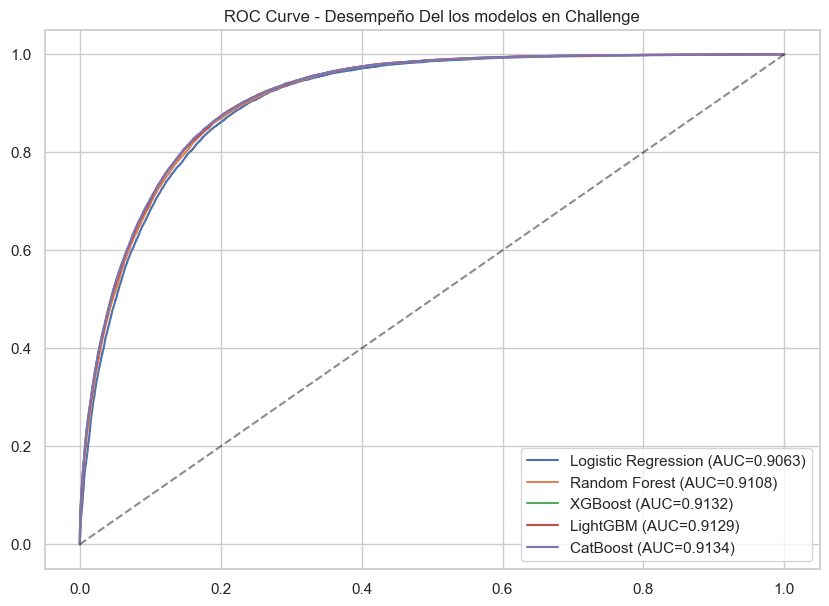

,Model,AUC Train,AUC Test,Diff,KS Test,KS Train
4,CatBoost,0.9197,0.9134,0.0063,0.6739,0.6868
2,XGBoost,0.9194,0.9132,0.0062,0.6737,0.6857
3,LightGBM,0.9149,0.9129,0.0020,0.6748,0.6771
1,Random Forest,0.9137,0.9108,0.0029,0.6704,0.6750
0,Logistic Regression,0.9063,0.9063,-0.0000,0.6630,0.6627


In [18]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve

set_config(transform_output="pandas")

df_model = df.copy(deep=True)
y = df_model['Churn'].map({'No': 0, 'Yes': 1}) if df_model['Churn'].dtype == 'object' else df_model['Churn']
X = df_model.drop('Churn', axis=1)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# PreProcesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('woe_enc', WOEEncoder(), cat_cols),
        ('keep_num', 'passthrough', num_cols)
    ]
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=11)
X_test, X_out, y_test, y_out = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=11)

# Modeos Del Challenge
r_st = 11
models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=r_st,class_weight='balanced'))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor),
        ("model", RandomForestClassifier(max_depth=10, random_state=r_st))
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocessor),
        ("model", XGBClassifier(random_state=r_st, eval_metric='logloss'))
    ]),
    "LightGBM": Pipeline([
        ("pre", preprocessor),
        ("model", LGBMClassifier(random_state=r_st, verbosity=-1))
    ]),
    "CatBoost": Pipeline([
        ("pre", preprocessor),
        ("model", CatBoostClassifier(random_state=r_st, verbose=0))
    ])
}

# Entrenamiento y Evaluación
results = []
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_probs = model.predict_proba(X_train)[:, 1]
    y_test_probs = model.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_train_probs)
    auc_test = roc_auc_score(y_test, y_test_probs)

    # KS
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    ks_test = max(tpr - fpr)
    
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_probs)
    ks_train = max(tpr_train - fpr_train)
    

    results.append({
        "Model": name,
        "AUC Train": round(auc_train, 4),
        "AUC Test": round(auc_test, 4),
        "Diff": round(auc_train - auc_test, 4),
        "KS Test": round(ks_test, 4),
        "KS Train": round(ks_train, 4)
    })

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_test:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("ROC Curve - Desempeño Del los modelos en Challenge")
plt.legend()
plt.show()


results_df = pd.DataFrame(results).sort_values("AUC Test", ascending=False)
display(results_df)

Se entrenaron cinco modelos utilizando un pipeline basado en **WOEEncoder** para transformar las variables categóricas y reducir el riesgo de fuga de información durante el entrenamiento. Los modelos de boosting —**CatBoost**, **LightGBM** y **XGBoost**— mostraron el mejor desempeño, alcanzando un **AUC de 0.9062** sobre el conjunto de prueba.  

Luego de comparar estabilidad, desempeño y costo computacional, se seleccionó **XGBoost** como modelo final para la predicción de churn, debido a su capacidad para generalizar correctamente, mantener tiempos de entrenamiento eficientes y ofrecer un rendimiento competitivo frente al resto de modelos evaluados.

In [19]:
print(f"cuenta de los 0: {y_out[y_out == 0].value_counts()}")
print(f"cuenta de los 1: {y_out[y_out == 1].value_counts()}")

cuenta de los 0: Churn
0    69057
Name: count, dtype: int64
cuenta de los 1: Churn
1    20073
Name: count, dtype: int64


## Modelo Baseline XGBoost.

c:\Users\jabes\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:751: UserWarning: [20:09:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


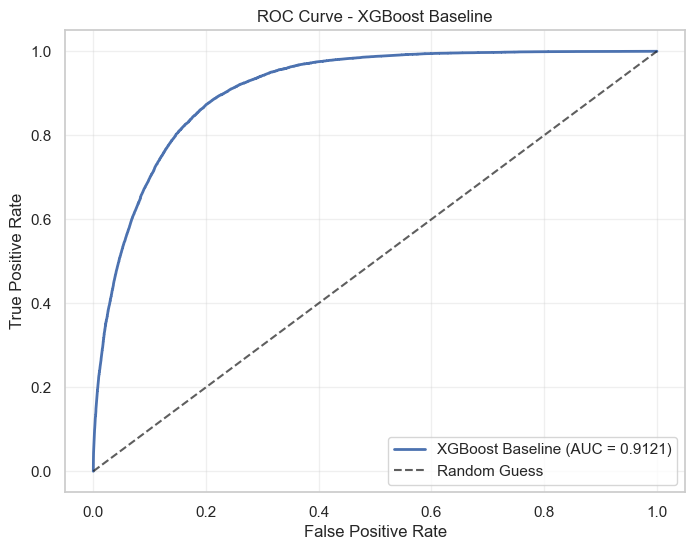

,Model,Diff,AUC Train,AUC Test,AUC Out,KS Train,KS Test,KS Out,Recall Train,Recall Test,F1 Train,F1 Test
0,XGBoost Baseline,0.000547,0.912622,0.912075,0.91348,0.672474,0.673065,0.675165,0.6402,0.6388,0.6692,0.6673


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from scipy.stats import ks_2samp

#  FUNCIÓN KS 
def calculate_ks(y_true, y_probs):
    df = pd.DataFrame({'target': y_true, 'prob': y_probs})
    buenos = df[df['target'] == 0]['prob']
    malos = df[df['target'] == 1]['prob']
    ks_stat, _ = ks_2samp(buenos, malos)
    return ks_stat


#  PARÁMETROS DEL BASELINE 
r_st = 11
models = {
    "XGBoost Baseline": XGBClassifier(
        random_state=r_st,
        max_depth=3,
        n_estimators=750,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',      
        reg_alpha=1,
        reg_lambda=2,
        min_child_weight=5,
        device="cuda",          
        tree_method="hist"      
    )
}



results = []   


preprocessor = ColumnTransformer(
    transformers=[
        ('woe_enc', WOEEncoder(), cat_cols),
        ('keep_num', 'passthrough', num_cols)
    ]
)

for name, estimator in models.items():
    
    pipeline = Pipeline([
        ('pre', preprocessor), 
        ('clf', estimator)
    ])
    
    pipeline.fit(X_train, y_train)

    # Predicciones de probabilidad
    y_train_probs = pipeline.predict_proba(X_train)[:, 1]
    y_test_probs  = pipeline.predict_proba(X_test)[:, 1]
    y_out_probs   = pipeline.predict_proba(X_out)[:, 1]

    #F1 & RECALL
    y_train_pred = (y_train_probs >= 0.5).astype(int)
    y_test_pred  = (y_test_probs  >= 0.5).astype(int)
    y_out_pred   = (y_out_probs   >= 0.5).astype(int)

    #  MÉTRICAS
    auc_train = roc_auc_score(y_train, y_train_probs)
    auc_test  = roc_auc_score(y_test,  y_test_probs)
    auc_out   = roc_auc_score(y_out,   y_out_probs)

    ks_train = calculate_ks(y_train, y_train_probs)
    ks_test  = calculate_ks(y_test,  y_test_probs)
    ks_out   = calculate_ks(y_out,   y_out_probs)

    diff = auc_train - auc_test

    recall_train = recall_score(y_train, y_train_pred)
    recall_test  = recall_score(y_test,  y_test_pred)
    recall_out   = recall_score(y_out,   y_out_pred)

    f1_train = f1_score(y_train, y_train_pred)
    f1_test  = f1_score(y_test,  y_test_pred)
    f1_out   = f1_score(y_out,   y_out_pred)

    # GUARDAR RESULTADOS 
    results.append({
        "Model":         name,
        "Diff":          round(diff, 6),
        "AUC Train":     round(auc_train, 6),
        "AUC Test":      round(auc_test, 6),
        "AUC Out":       round(auc_out, 6),
        "KS Train":      round(ks_train, 6),
        "KS Test":       round(ks_test, 6),
        "KS Out":        round(ks_out, 6),
        "Recall Train":  round(recall_train, 4),
        "Recall Test":   round(recall_test, 4),
        "F1 Train":      round(f1_train, 4),
        "F1 Test":       round(f1_test, 4),

    })
fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost Baseline (AUC = {auc_test:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random Guess')
plt.title("ROC Curve - XGBoost Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


results_df_model = pd.DataFrame(results)
display(results_df_model)

## Busqueda de HiperParametros para con Optuna.

## XGBOOST + Optuna.

In [21]:
import warnings
import numpy as np
import optuna
from optuna.samplers import TPESampler
from optuna.integration.xgboost import XGBoostPruningCallback
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Silenciar warnings innecesarios
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)

def objective(trial):
    max_d = trial.suggest_int("max_depth", 3, 8)
    max_leaves_limit = min(255, 2**max_d)

    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 600, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "max_depth":         max_d,
        "grow_policy":       "lossguide",
        "max_leaves":        trial.suggest_int("max_leaves", 8, max_leaves_limit),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 2, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.5, 3.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 4.0),
        "gamma":             trial.suggest_float("gamma", 1, 5),

        "random_state":      11,
        "device":            "cuda",
        "tree_method":       "hist",
        "eval_metric":       "auc",  # Correcto: ya está configurado para el constructor
        "verbosity":         0
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    auc_val_list   = []
    auc_train_list = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Preprocesamiento (WOE necesita target)
        X_tr_prep = preprocessor.fit_transform(X_tr, y_tr)
        X_val_prep = preprocessor.transform(X_val)

        # 1. Definir la lista de callbacks primero
        callbacks = []
        if fold == 0:
            pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")
            callbacks.append(pruning_callback)

        # 2. CORRECCIÓN: Instanciar el modelo pasando los callbacks al constructor
        model = XGBClassifier(**params, callbacks=callbacks)

        # 3. CORRECCIÓN: El método .fit() ya no recibe el parámetro callbacks
        model.fit(
            X_tr_prep, y_tr,
            eval_set=[(X_val_prep, y_val)],
            verbose=False
        )

        # Evaluación
        val_preds = model.predict_proba(X_val_prep)[:, 1]
        auc_v = roc_auc_score(y_val, val_preds)
        auc_val_list.append(auc_v)

        train_preds = model.predict_proba(X_tr_prep)[:, 1]
        auc_t = roc_auc_score(y_tr, train_preds)
        auc_train_list.append(auc_t)

    # Métricas finales del trial
    auc_val_mean   = np.mean(auc_val_list)
    auc_train_mean = np.mean(auc_train_list)

    diff = abs(auc_train_mean - auc_val_mean)
    penalty = diff * 1.9 if diff > 0.02 else 0

    trial.set_user_attr("auc_train", round(auc_train_mean, 6))
    trial.set_user_attr("overfit_diff", round(diff, 6))

    return auc_val_mean - penalty


# ====================== EJECUCIÓN ======================
semilla_optuna = TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    sampler=semilla_optuna,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=10)
)

study.optimize(objective, n_trials=150, show_progress_bar=True)

print("¡Optimización Completa!")
print(f"Mejor AUC en validación: {study.best_value:.5f}")
print(f"Mejores parámetros: {study.best_params}")

  0%|          | 0/150 [00:00<?, ?it/s]

¡Optimización Completa!
Mejor AUC en validación: 0.91378
Mejores parámetros: {'max_depth': 8, 'n_estimators': 916, 'learning_rate': 0.04437663286592385, 'max_leaves': 150, 'subsample': 0.7711527693224844, 'colsample_bytree': 0.7460423889078052, 'min_child_weight': 2, 'reg_alpha': 2.9651688031993704, 'reg_lambda': 3.7594479797148703, 'gamma': 1.2408287709593915}


In [22]:
print("AUC Test:", roc_auc_score(y_test, y_test_probs))
print("Mejores hiperparámetros:", study.best_params)

AUC Test: 0.9120754445846755
Mejores hiperparámetros: {'max_depth': 8, 'n_estimators': 916, 'learning_rate': 0.04437663286592385, 'max_leaves': 150, 'subsample': 0.7711527693224844, 'colsample_bytree': 0.7460423889078052, 'min_child_weight': 2, 'reg_alpha': 2.9651688031993704, 'reg_lambda': 3.7594479797148703, 'gamma': 1.2408287709593915}


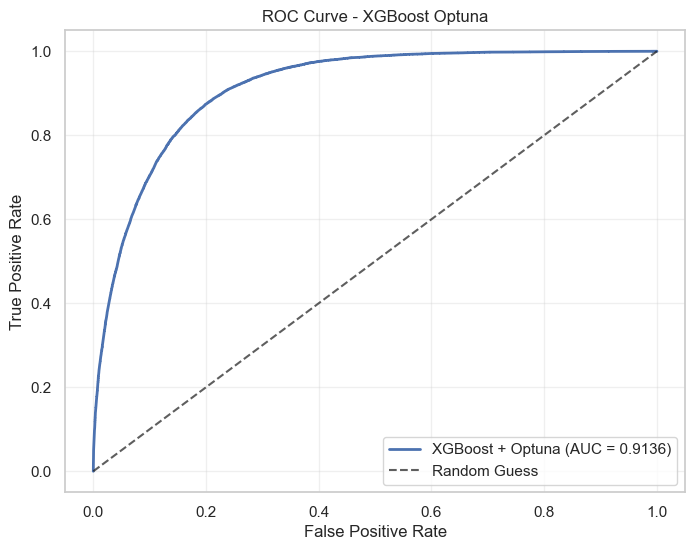

<Figure size 600x500 with 0 Axes>

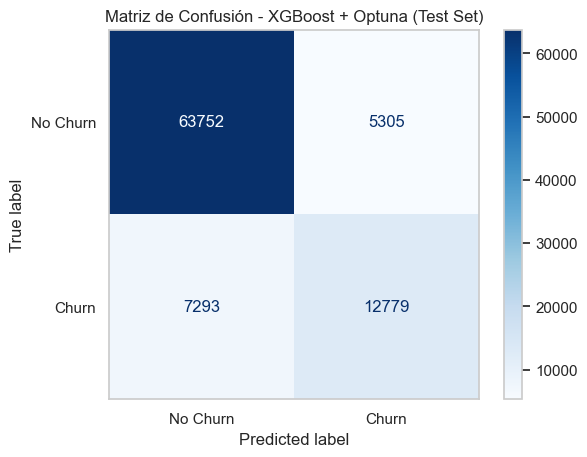

,Model,Diff,AUC Train,AUC Test,AUC Out,KS Train,KS Test,KS Out,Recall Train,Recall Test,F1 Train,F1 Test,Recall Out,F1 Out
0,XGBoost Baseline,0.000547,0.912622,0.912075,0.913480,0.672474,0.673065,0.675165,0.6402,0.6388,0.6692,0.6673,NaN,NaN
1,XGBoost + Optuna,0.004088,0.917668,0.913580,0.914733,0.683107,0.674357,0.676765,0.6412,0.6367,0.6757,0.6698,0.6402,0.6743


In [23]:

from scipy.stats import ks_2samp  


best_params = study.best_params

final_pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        **best_params,
        device="cuda",          
        tree_method="hist",
        random_state=11,
        verbosity=0,
        eval_metric="auc"
    ))
])

final_pipeline_xgb.fit(X_train, y_train)

y_train_probs = final_pipeline_xgb.predict_proba(X_train)[:, 1]
y_test_probs  = final_pipeline_xgb.predict_proba(X_test)[:, 1]
y_out_probs   = final_pipeline_xgb.predict_proba(X_out)[:, 1]

y_train_pred = (y_train_probs >= 0.5).astype(int)
y_test_pred  = (y_test_probs  >= 0.5).astype(int)
y_out_pred   = (y_out_probs   >= 0.5).astype(int)

# MÉTRICAS
auc_train = roc_auc_score(y_train, y_train_probs)
auc_test  = roc_auc_score(y_test,  y_test_probs)
auc_out   = roc_auc_score(y_out,   y_out_probs)

ks_train = calculate_ks(y_train, y_train_probs)
ks_test  = calculate_ks(y_test,  y_test_probs)
ks_out   = calculate_ks(y_out,   y_out_probs)

diff = auc_train - auc_test

recall_train = recall_score(y_train, y_train_pred)
recall_test  = recall_score(y_test,  y_test_pred)
recall_out   = recall_score(y_out,   y_out_pred)

f1_train = f1_score(y_train, y_train_pred)
f1_test  = f1_score(y_test,  y_test_pred)
f1_out   = f1_score(y_out,   y_out_pred)


results.append({
    "Model":        "XGBoost + Optuna",
    "Diff":         round(diff, 6),
    "AUC Train":    round(auc_train, 6),
    "AUC Test":     round(auc_test, 6),
    "AUC Out":      round(auc_out, 6),
    "KS Train":     round(ks_train, 6),
    "KS Test":      round(ks_test, 6),
    "KS Out":       round(ks_out, 6),
    "Recall Train": round(recall_train, 4),
    "Recall Test":  round(recall_test, 4),
    "Recall Out":   round(recall_out, 4),
    "F1 Train":     round(f1_train, 4),
    "F1 Test":      round(f1_test, 4),
    "F1 Out":       round(f1_out, 4),

})

#  GRÁFICA ROC
fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost + Optuna (AUC = {auc_test:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random Guess')
plt.title("ROC Curve - XGBoost Optuna")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - XGBoost + Optuna (Test Set)")
plt.grid(False)
plt.show()


results_df_model = pd.DataFrame(results)
display(results_df_model)

## Optuna + LigthGBM

In [24]:
import warnings
from optuna.samplers import TPESampler
from optuna.integration import LightGBMPruningCallback
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)

def objective_lgbm(trial):
    max_d = trial.suggest_int("max_depth", 3, 8)
    num_leaves_limit = min(255, (2**max_d) - 1)

    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 600, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "max_depth":         max_d,
        "num_leaves":        trial.suggest_int("num_leaves", 7, num_leaves_limit),         
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100), 
        "min_child_weight":  trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.5, 3.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 4.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 1e-3, 5, log=True),
        "random_state":      11,
        "device_type":       "gpu", 
        "metric":            "auc",
        "verbose":           -1
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=555)
    auc_val_list   = []
    auc_train_list = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Preprocesamiento WoE (importante: fit con target)
        X_tr_prep = preprocessor.fit_transform(X_tr, y_tr)
        X_val_prep = preprocessor.transform(X_val)

        model = LGBMClassifier(**params)

        callbacks = []
        if fold == 0:  # Pruning solo en el primer fold
            pruning_callback = LightGBMPruningCallback(trial, "auc")
            callbacks.append(pruning_callback)

        model.fit(
            X_tr_prep, y_tr,
            eval_set=[(X_val_prep, y_val)],
            eval_names=["valid_0"],   # Nombre explícito para el callback
            callbacks=callbacks
        )

        # Evaluación
        val_preds = model.predict_proba(X_val_prep)[:, 1]
        auc_v = roc_auc_score(y_val, val_preds)
        auc_val_list.append(auc_v)

        train_preds = model.predict_proba(X_tr_prep)[:, 1]
        auc_t = roc_auc_score(y_tr, train_preds)
        auc_train_list.append(auc_t)

    # Métricas del trial
    auc_val_mean   = np.mean(auc_val_list)
    auc_train_mean = np.mean(auc_train_list)

    diff = abs(auc_train_mean - auc_val_mean)
    penalty = diff * 1.9 if diff > 0.02 else 0

    trial.set_user_attr("auc_train", round(auc_train_mean, 6))
    trial.set_user_attr("overfit_diff", round(diff, 6))

    return auc_val_mean - penalty



semilla_optuna = TPESampler(seed=42)

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=semilla_optuna,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=10)
)

study_lgbm.optimize(objective_lgbm, n_trials=150, show_progress_bar=True)

print(f"Mejor AUC Penalizado: {study_lgbm.best_value:.5f}")
print(f"Mejores parámetros: {study_lgbm.best_params}")

  0%|          | 0/150 [00:00<?, ?it/s]

Mejor AUC Penalizado: 0.91392
Mejores parámetros: {'max_depth': 8, 'n_estimators': 652, 'learning_rate': 0.0402662859282968, 'num_leaves': 98, 'subsample': 0.9213801165054094, 'colsample_bytree': 0.7455497607771112, 'min_child_samples': 88, 'min_child_weight': 0.008166160055834983, 'reg_alpha': 1.1622942410546522, 'reg_lambda': 3.0798278220240283, 'min_split_gain': 0.09715941382828437}


# Study + LigthGBM

Entrenando el modelo LightGBM definitivo...


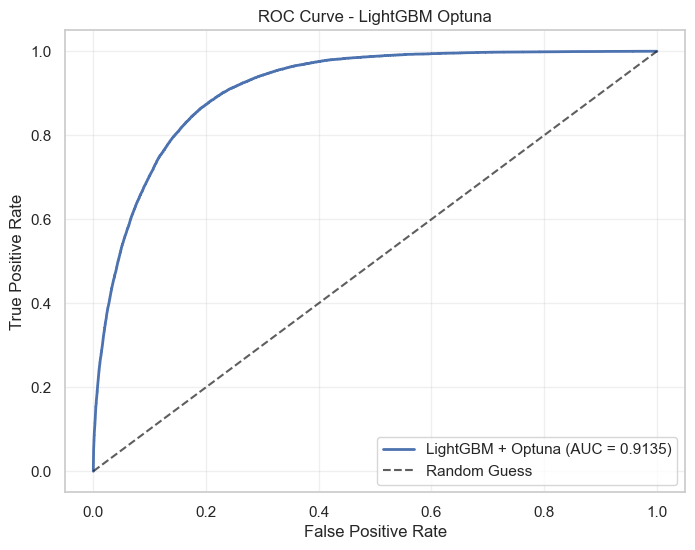

<Figure size 600x500 with 0 Axes>

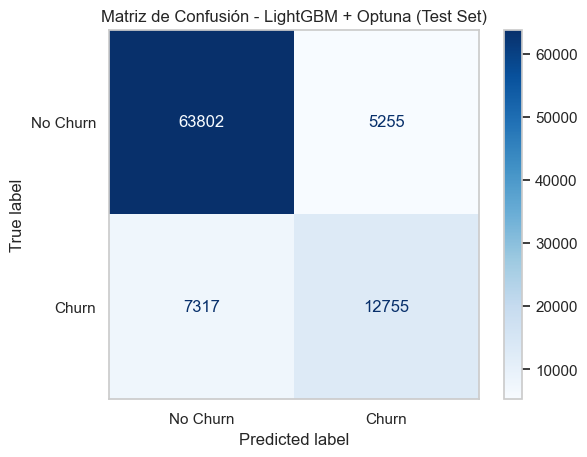

,Model,Diff,AUC Train,AUC Test,AUC Out,KS Train,KS Test,KS Out,Recall Train,Recall Test,F1 Train,F1 Test,Recall Out,F1 Out
0,XGBoost Baseline,0.000547,0.912622,0.912075,0.913480,0.672474,0.673065,0.675165,0.6402,0.6388,0.6692,0.6673,NaN,NaN
1,XGBoost + Optuna,0.004088,0.917668,0.913580,0.914733,0.683107,0.674357,0.676765,0.6412,0.6367,0.6757,0.6698,0.6402,0.6743
2,LightGBM + Optuna,0.004316,0.917799,0.913484,0.914664,0.682413,0.673783,0.677080,0.6405,0.6355,0.6757,0.6699,0.6400,0.6746


In [25]:
best_params_lgbm = study_lgbm.best_params.copy()

final_pipeline_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        **best_params_lgbm,
        device_type="gpu",
        random_state=11,
        verbose=-1,
        metric="auc"
    ))
])

print("Entrenando el modelo LightGBM definitivo...")
final_pipeline_lgbm.fit(X_train, y_train)

# PREDICCIONES 
y_train_probs = final_pipeline_lgbm.predict_proba(X_train)[:, 1]
y_test_probs  = final_pipeline_lgbm.predict_proba(X_test)[:, 1]
y_out_probs   = final_pipeline_lgbm.predict_proba(X_out)[:, 1]

y_train_pred = (y_train_probs >= 0.5).astype(int)
y_test_pred  = (y_test_probs  >= 0.5).astype(int)
y_out_pred   = (y_out_probs   >= 0.5).astype(int)

#  MÉTRICAS 
auc_train = roc_auc_score(y_train, y_train_probs)
auc_test  = roc_auc_score(y_test,  y_test_probs)
auc_out   = roc_auc_score(y_out,   y_out_probs)

ks_train = calculate_ks(y_train, y_train_probs)
ks_test  = calculate_ks(y_test,  y_test_probs)
ks_out   = calculate_ks(y_out,   y_out_probs)

diff = auc_train - auc_test

recall_train = recall_score(y_train, y_train_pred)
recall_test  = recall_score(y_test,  y_test_pred)
recall_out   = recall_score(y_out,   y_out_pred)

f1_train = f1_score(y_train, y_train_pred)
f1_test  = f1_score(y_test,  y_test_pred)
f1_out   = f1_score(y_out,   y_out_pred)


results.append({
    "Model":        "LightGBM + Optuna",
    "Diff":         round(diff, 6),
    "AUC Train":    round(auc_train, 6),
    "AUC Test":     round(auc_test, 6),
    "AUC Out":      round(auc_out, 6),
    "KS Train":     round(ks_train, 6),
    "KS Test":      round(ks_test, 6),
    "KS Out":       round(ks_out, 6),
    "Recall Train": round(recall_train, 4),
    "Recall Test":  round(recall_test, 4),
    "Recall Out":   round(recall_out, 4),
    "F1 Train":     round(f1_train, 4),
    "F1 Test":      round(f1_test, 4),
    "F1 Out":       round(f1_out, 4)
})

#  GRÁFICA ROC 
fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM + Optuna (AUC = {auc_test:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random Guess')
plt.title("ROC Curve - LightGBM Optuna")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - LightGBM + Optuna (Test Set)")
plt.grid(False)
plt.show()


results_df_model = pd.DataFrame(results)
display(results_df_model)

## Selecion de modelo Final



* Aunque XGBoost obtuvo marginalmente las mejores métricas de AUC y KS, las diferencias observadas respecto a LightGBM fueron insignificantes desde el punto de vista práctico. Dado que ambos modelos presentan una capacidad predictiva y estabilidad muy similares, se seleccionó LightGBM como modelo final por ofrecer un desempeño equivalente con una menor complejidad computacional y tiempos de entrenamiento más eficientes, manteniendo una excelente capacidad de generalización entre los conjuntos Train, Test y Out-of-Time.

## Calibracion

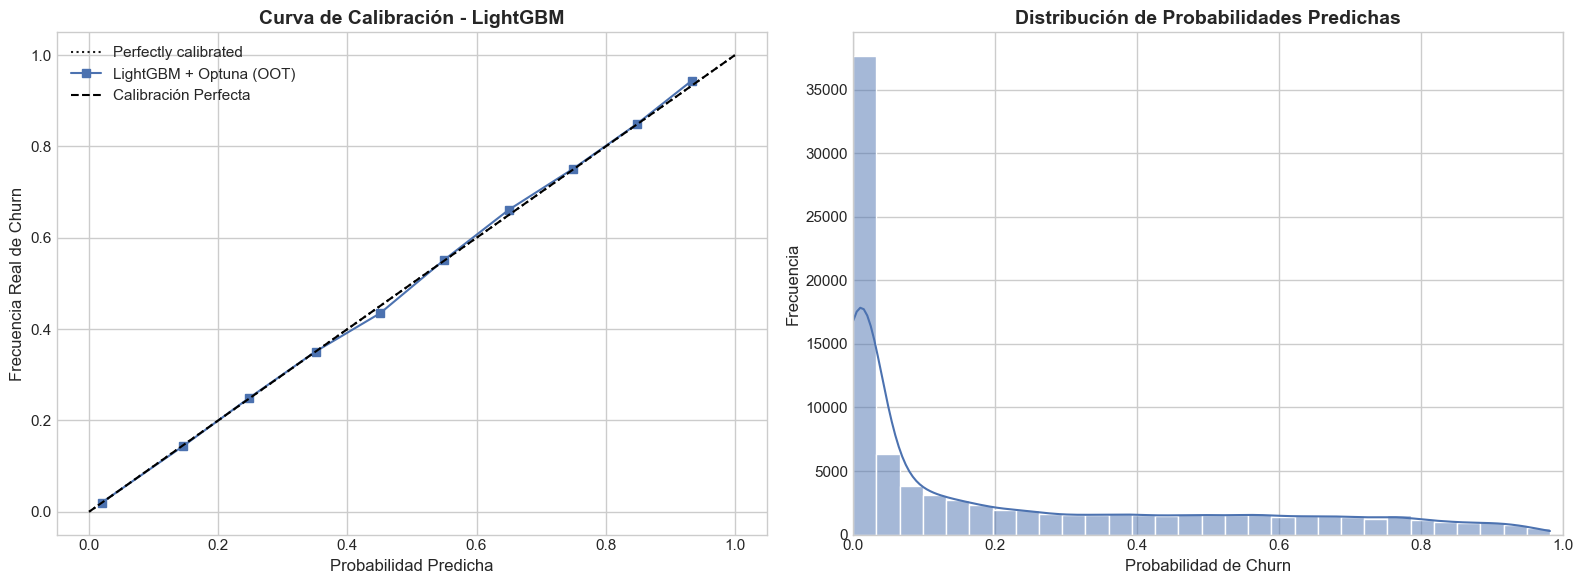

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibrationDisplay

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# ==========================================================
# CURVA DE CALIBRACIÓN
# ==========================================================

CalibrationDisplay.from_predictions(y_out, y_out_probs, n_bins=10, name="LightGBM + Optuna (OOT)", ax=ax1
)

ax1.plot([0, 1], [0, 1], linestyle="--", color="black", label="Calibración Perfecta")

ax1.set_title( "Curva de Calibración - LightGBM", fontsize=14, fontweight="bold"
)

ax1.set_xlabel(
    "Probabilidad Predicha"
)

ax1.set_ylabel(
    "Frecuencia Real de Churn"
)

ax1.legend()

# ==========================================================
# DISTRIBUCIÓN DE SCORES
# ==========================================================

sns.histplot( y_out_probs, bins=30, kde=True, ax=ax2)

ax2.set_title(
    "Distribución de Probabilidades Predichas",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Probabilidad de Churn")

ax2.set_ylabel("Frecuencia")

ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_test_probs)

print(f"Brier Score: {brier:.5f}")

Brier Score: 0.09676


## Conclusiones de calibracion

La calibración del modelo fue evaluada sobre el conjunto Out-of-Time (OOT) con el objetivo de verificar la confiabilidad de las probabilidades estimadas en un período temporal distinto al utilizado durante el entrenamiento. La curva de calibración mostró una alineación casi perfecta con la línea de calibración ideal, evidenciando que las probabilidades predichas mantienen una correspondencia adecuada con las tasas reales observadas de churn.

Adicionalmente, el modelo obtuvo un Brier Score de 0.09629 sobre el conjunto OOT, valor que indica una excelente calidad probabilística de las predicciones. En conjunto con los resultados de AUC (0.9146) y KS (0.6771), estos hallazgos sugieren que el modelo presenta una adecuada capacidad de discriminación y una correcta estimación del riesgo.

Por lo tanto, no se consideró necesario aplicar técnicas adicionales de recalibración, ya que las probabilidades generadas por el modelo resultan suficientemente interpretables y confiables para fines analíticos y de toma de decisiones.


## SHAP LightGBM

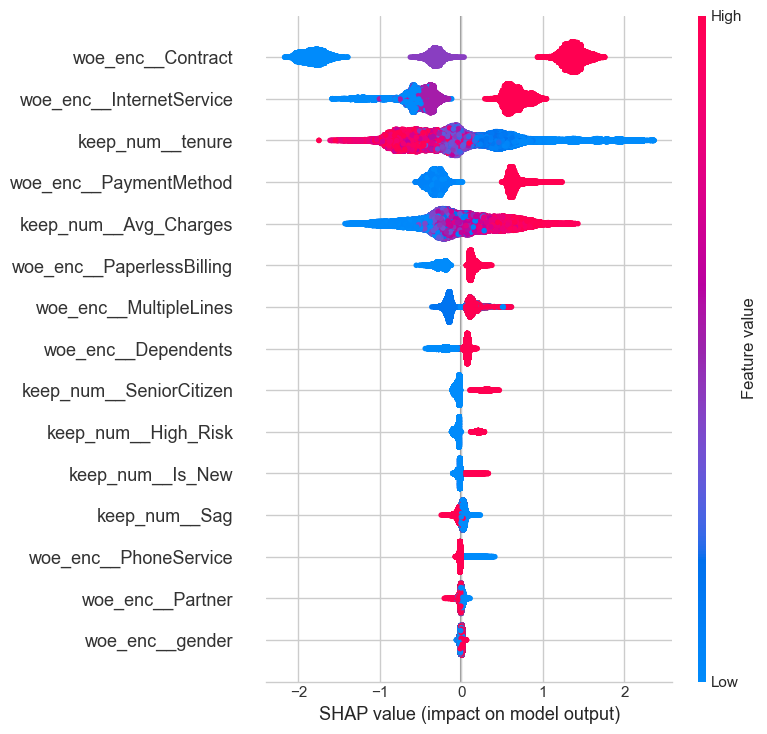

In [28]:
preprocessor_fitted = final_pipeline_lgbm.named_steps["preprocessor"]
model_fitted = final_pipeline_lgbm.named_steps["model"]

X_test_shap = preprocessor_fitted.transform(X_test)

feature_names = preprocessor_fitted.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_shap,
    columns=feature_names
)

explainer = shap.TreeExplainer(model_fitted)
shap_values = explainer(X_test_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]


shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=20
)

* Conclusión ejecutiva: El modelo identifica que el riesgo de fuga está dominado por el tipo de contrato, el tipo de servicio de Internet y la antigüedad del cliente (tenure). Los clientes recientes presentan mayor probabilidad predicha de churn, mientras que los clientes con mayor antigüedad muestran mayor estabilidad. El método de pago y algunas características adicionales contribuyen al riesgo, pero con una magnitud claramente menor que las variables principales.

## Calculando el precio de clientes sin servicios VS clientes con servicios.

In [29]:
import ipywidgets as widgets
from IPython.display import display, HTML

# calcula y renderiza el Dashboard
def calcular_roi_interactivo(clientes_riesgo, tarifa_mensual, costo_retencion, cac, tasa_exito_pct):
    tasa_exito = tasa_exito_pct / 100.0
    

    ingreso_en_riesgo = clientes_riesgo * tarifa_mensual * 12
    inversion = clientes_riesgo * costo_retencion
    salvados = int(clientes_riesgo * tasa_exito)
    ingreso_recuperado = salvados * tarifa_mensual * 12
    ahorro_cac = salvados * cac
    
    roi_neto = (ingreso_recuperado + ahorro_cac) - inversion
    
    # HTML
    color_roi = "#27ae60" if roi_neto >= 0 else "#c0392b" 
    
    html_str = f"""
    <div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6; font-family: Arial, sans-serif;">
        <h2 style="color: #2c3e50; text-align: center; margin-bottom: 20px;"> Dashboard de Impacto Financiero ROI (set oot)</h2>
        
        <div style="display: flex; justify-content: space-around; margin-bottom: 20px;">
            <div style="background-color: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); width: 30%; text-align: center;">
                <h4 style="color: #7f8c8d; margin: 0;">Ingreso en Riesgo (Anual)</h4>
                <h3 style="color: #e74c3c; margin: 10px 0;">${ingreso_en_riesgo:,.2f}</h3>
                <p style="font-size: 12px; color: #95a5a6;">Si no hacemos nada</p>
            </div>
            
            <div style="background-color: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); width: 30%; text-align: center;">
                <h4 style="color: #7f8c8d; margin: 0;">Inversión en Retención</h4>
                <h3 style="color: #f39c12; margin: 10px 0;">-${inversion:,.2f}</h3>
                <p style="font-size: 12px; color: #95a5a6;">Costo de la campaña</p>
            </div>
            
            <div style="background-color: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); width: 30%; text-align: center;">
                <h4 style="color: #7f8c8d; margin: 0;">Clientes Salvados</h4>
                <h3 style="color: #3498db; margin: 10px 0;">{salvados:,}</h3>
                <p style="font-size: 12px; color: #95a5a6;">De {clientes_riesgo:,} detectados</p>
            </div>
        </div>
        
        <div style="background-color: #fff; padding: 20px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center;">
            <h3 style="color: #2c3e50; margin-bottom: 15px;">Resultados de la Intervención</h3>
            <p style="font-size: 16px; margin: 5px;">Ingresos mensuales Protegidos: <b style="color:#27ae60;">+${ingreso_recuperado:,.2f}</b></p>
            <p style="font-size: 16px; margin: 5px;">Ahorro en Costo de Adquisición (CAC): <b style="color:#27ae60;">+${ahorro_cac:,.2f}</b></p>
            <hr style="border-top: 1px solid #ecf0f1; margin: 15px 0;">
            <h2 style="color: {color_roi}; margin: 0; font-size: 28px;">ROI Neto: ${roi_neto:,.2f}</h2>
        </div>
    </div>
    """
    display(HTML(html_str))

# Sliders Interactivos
style = {'description_width': 'initial'}
layout = widgets.Layout(width='600px')

w_clientes = widgets.IntSlider(value=300, min=50, max=5000, step=10, description='Clientes con Riesgo:', style=style, layout=layout)
# Por defecto tu tarifa de 65.86
w_tarifa = widgets.FloatSlider(value=65.86, min=10.0, max=150.0, step=0.5, description='Pago Mensual USD: ', style=style, layout=layout)
w_costo = widgets.FloatSlider(value=20.0, min=5.0, max=100.0, step=5.0, description='Costo de Retención por Cliente USD:', style=style, layout=layout)
w_cac = widgets.FloatSlider(value=120.0, min=50.0, max=500.0, step=10.0, description='Costo de Adquisición CAC USD:', style=style, layout=layout)
w_exito = widgets.IntSlider(value=25, min=1, max=100, step=1, description='Tasa de Éxito de la Campaña (%):', style=style, layout=layout)

# Agrupación y despliegue 
controles = widgets.VBox([w_clientes, w_tarifa, w_costo, w_cac, w_exito])
salida_interactiva = widgets.interactive_output(
    calcular_roi_interactivo, 
    {'clientes_riesgo': w_clientes, 'tarifa_mensual': w_tarifa, 'costo_retencion': w_costo, 'cac': w_cac, 'tasa_exito_pct': w_exito}
)

display(controles, salida_interactiva)

Output()

**Conclusión**

El presente proyecto permitió desarrollar un modelo de Machine Learning orientado a la predicción del abandono de clientes (Churn), partiendo de un proceso integral de análisis exploratorio, transformación de variables, ingeniería de características, selección de variables y evaluación de diferentes algoritmos de clasificación. El conjunto de datos utilizado contiene 594,194 registros y 20 variables, sin valores nulos, permitiendo construir un flujo de preparación y modelado sobre una base de datos consistente.

Durante el análisis se identificaron diferentes patrones asociados al comportamiento de los clientes, los servicios contratados, la antigüedad, el tipo de contrato y los métodos de pago. A partir de estos hallazgos se construyeron variables derivadas como Sag, Is_New, Avg_Charges y High_Risk, buscando representar de forma más compacta y significativa determinados patrones relacionados con el riesgo de abandono.

La comparación de diferentes estrategias de codificación y modelos permitió establecer un proceso de selección basado en evidencia, en lugar de depender únicamente de una elección arbitraria del algoritmo. Asimismo, el uso de WOE, IV y VIF permitió complementar la evaluación predictiva con criterios de capacidad discriminatoria, interpretabilidad y control de multicolinealidad.

Finalmente, la optimización de hiperparámetros permitió mejorar el desempeño del modelo seleccionado respecto al escenario base. La evaluación mediante AUC y KS, complementada con la validación fuera de muestra, permite determinar la capacidad del modelo para diferenciar entre clientes con mayor y menor probabilidad de abandono.

Desde una perspectiva de negocio, el valor principal del modelo no reside únicamente en predecir quién podría abandonar, sino en transformar esa probabilidad en una herramienta de priorización para las estrategias de retención. De esta manera, la empresa puede concentrar sus recursos en aquellos clientes que presentan un mayor nivel de riesgo, permitiendo diseñar acciones de retención más focalizadas y potencialmente más eficientes.

Es importante señalar que el modelo identifica asociaciones predictivas y niveles de riesgo, pero no demuestra causalidad entre las variables y el abandono. Por tanto, cualquier estrategia de retención derivada de sus resultados deberá ser posteriormente validada mediante experimentación o medición de impacto real.

En conclusión, el proyecto demuestra cómo un flujo completo de Data Science —desde la exploración y transformación de los datos hasta la optimización y evaluación de un modelo predictivo— puede convertirse en una herramienta orientada a la toma de decisiones, estableciendo una base para futuras mejoras mediante monitoreo del modelo, calibración de probabilidades, análisis de drift y validación continua de su impacto económico.